In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

import matplotlib.pyplot as plt

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv("mumbai_prediction_model_panel.csv")


# CLEAN DATA

df.columns = df.columns.str.strip()


# Sort panel data

df = df.sort_values(
    ["spatial_id","year","month"]
).reset_index(drop=True)

# CHECK

print(df.shape)
print(df["city"].value_counts())

# Load Spatial File

spatial_df = pd.read_csv(
    "mumbai_prediction_model_panel.csv"
)

print(spatial_df.shape)

spatial_df = spatial_df[
    [
        "spatial_id",
        "year",
        "month",
        "centroid_lon",
        "centroid_lat"
    ]
].drop_duplicates()

print(spatial_df.shape)

(3108, 30)
city
mumbai    3108
Name: count, dtype: int64
(3108, 30)
(3108, 5)


In [3]:
print(df.columns.tolist())

['city', 'spatial_id', 'year', 'month', 'tci', 'no2', 'era5_temp', 'centroid_lon', 'centroid_lat', 'holiday_is_off_days', 'wind_speed', 'population', 'building_height', 'pt_count_points', 'pt_count_lines', 'pt_count_polygon', 'pt_total', 'road_length_motorway_m', 'road_length_primary_m', 'road_length_residential_m', 'road_length_secondary_m', 'road_length_tertiary_m', 'road_length_trunk_m', 'road_length_unclassified_m', 'road_length_total_m', 'poi_business_n_business', 'poi_commercial_n_commercial', 'poi_education_n_education', 'poi_leisure_n_leisure', 'power_plant_n_power_plant']


In [4]:
# ============================================================
# INPUT VARIABLES
# ============================================================

y_var = "tci"

In [5]:
# ------------------------------------------------------------
# Model 1 
# TCI ~ NO2
# ------------------------------------------------------------

model1_vars = [
    "no2"
]

In [6]:
# ------------------------------------------------------------
# MODEL 2
# ALL VARIABLES
# ------------------------------------------------------------

model2_vars = [
    "no2",
    "era5_temp",
    "holiday_is_off_days",
    "wind_speed",
    "population",
    "building_height",
    "pt_count_points",
    "pt_count_lines",
    "pt_count_polygon",
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
    "power_plant_n_power_plant"
]

In [7]:
# ------------------------------------------------------------
# MODEL 3
# EXCLUDING ERA5_TEMP, HOLIDAY, WIND + MONTH FE
# ------------------------------------------------------------

model3_vars = model2_vars.copy()

for var in ["era5_temp", "holiday_is_off_days", "wind_speed"]:
    if var in model2_vars:
        model3_vars.remove(var)

In [8]:
# Clean Data Function

def clean_dataset(
    data,
    y_var,
    x_vars
):

    cols = [y_var] + x_vars

    temp = data[cols].copy()

    temp = temp.replace(
        [np.inf, -np.inf],
        np.nan
    )

    temp = temp.dropna()

    return temp

In [9]:
# ============================================================
# VIF FUNCTION AND CHECK
# ============================================================

def clean_dataset(
    data,
    y_var,
    x_vars
):

    cols = [y_var] + x_vars

    temp = data[cols].copy()

    temp = temp.replace(
        [np.inf, -np.inf],
        np.nan
    )

    temp = temp.dropna()

    return temp

def calculate_vif(X):

    X = X.copy()

    # Keep only numeric variables
    X = X.select_dtypes(include=[np.number])

    # Remove infinities
    X = X.replace([np.inf, -np.inf], np.nan)

    # Remove rows with missing values
    X = X.dropna()

    # Remove constant columns
    constant_cols = [
        col for col in X.columns
        if X[col].nunique() <= 1
    ]

    if len(constant_cols) > 0:
        print("Removing constant columns:")
        print(constant_cols)

        X = X.drop(columns=constant_cols)

    vif = pd.DataFrame()

    vif["Variable"] = X.columns

    vif["VIF"] = [
        variance_inflation_factor(
            X.values,
            i
        )
        for i in range(X.shape[1])
    ]

    return vif.sort_values(
        by="VIF",
        ascending=False
    )

print("="*80)
print("MODEL 1 VIF")
print("="*80)

print("="*80)
print("MODEL 2 VIF")
print("="*80)

temp_m2 = clean_dataset(
    df,
    y_var,
    model2_vars
)

vif_m2 = calculate_vif(
    temp_m2[model2_vars]
)

print(vif_m2)

print("="*80)
print("MODEL 3 VIF")
print("="*80)

temp_m3 = clean_dataset(
    df,
    y_var,
    model3_vars
)

vif_m3 = calculate_vif(
    temp_m3[model3_vars]
)

print(vif_m3)


MODEL 1 VIF
MODEL 2 VIF
                       Variable         VIF
1                     era5_temp  180.691744
2           holiday_is_off_days   81.928908
3                    wind_speed   34.750829
4                    population   26.731732
5               building_height   17.381397
11    road_length_residential_m    9.518043
0                           no2    8.869728
13       road_length_tertiary_m    4.031965
12      road_length_secondary_m    2.938432
6               pt_count_points    2.868414
10        road_length_primary_m    2.604755
18    poi_education_n_education    1.983112
16      poi_business_n_business    1.810220
17  poi_commercial_n_commercial    1.683533
19        poi_leisure_n_leisure    1.625238
8              pt_count_polygon    1.439005
14          road_length_trunk_m    1.420641
9        road_length_motorway_m    1.236521
15   road_length_unclassified_m    1.185039
7                pt_count_lines    1.101138
20    power_plant_n_power_plant    1.028846
MODEL 3 

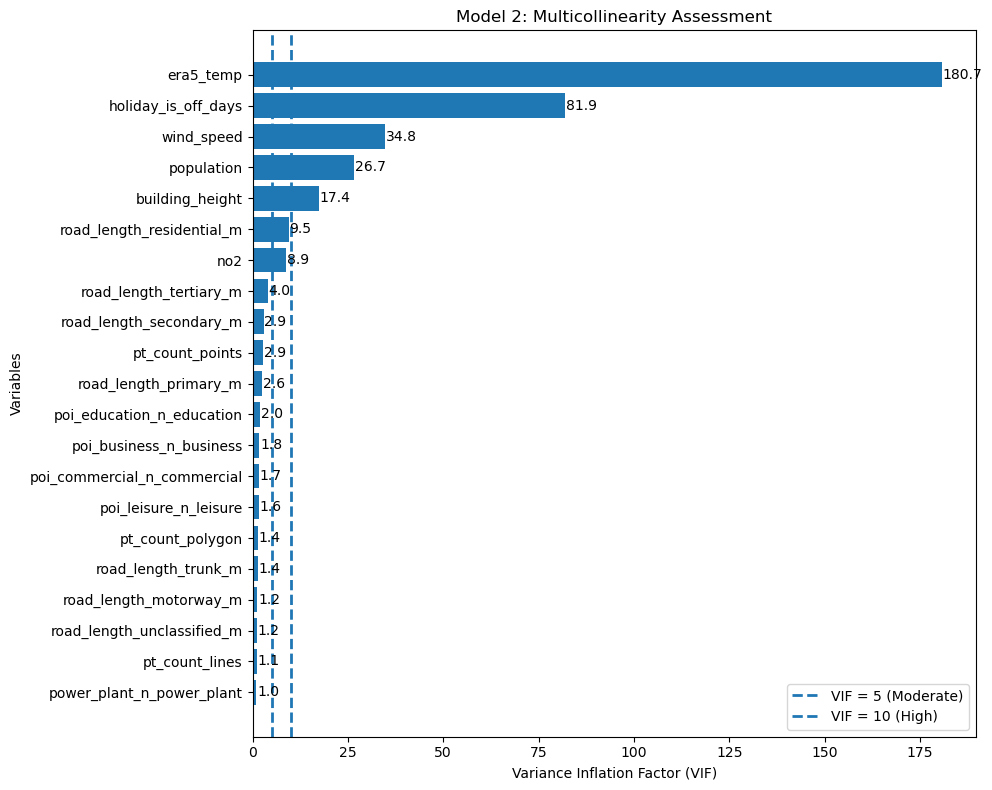

In [10]:
# ------------------------------------------------------------
# VIF BAR CHART - MODEL 2
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Copy dataframe
vif_plot = vif_m2.copy()

# Hapus intercept/constant kalau ada
vif_plot = vif_plot[
    ~vif_plot["Variable"].str.contains(
        "const",
        case=False,
        na=False
    )
]

# Urutkan
vif_plot = vif_plot.sort_values(
    "VIF",
    ascending=True
)

# Plot
plt.figure(
    figsize=(10,8)
)

bars = plt.barh(
    vif_plot["Variable"],
    vif_plot["VIF"]
)

# Threshold lines
plt.axvline(
    x=5,
    linestyle="--",
    linewidth=2,
    label="VIF = 5 (Moderate)"
)

plt.axvline(
    x=10,
    linestyle="--",
    linewidth=2,
    label="VIF = 10 (High)"
)

# Value labels
for i, value in enumerate(vif_plot["VIF"]):

    plt.text(
        value + 0.2,
        i,
        f"{value:.1f}",
        va="center"
    )

plt.xlabel(
    "Variance Inflation Factor (VIF)"
)

plt.ylabel(
    "Variables"
)

plt.title(
    "Model 2: Multicollinearity Assessment"
)

plt.legend()

plt.tight_layout()

plt.show()

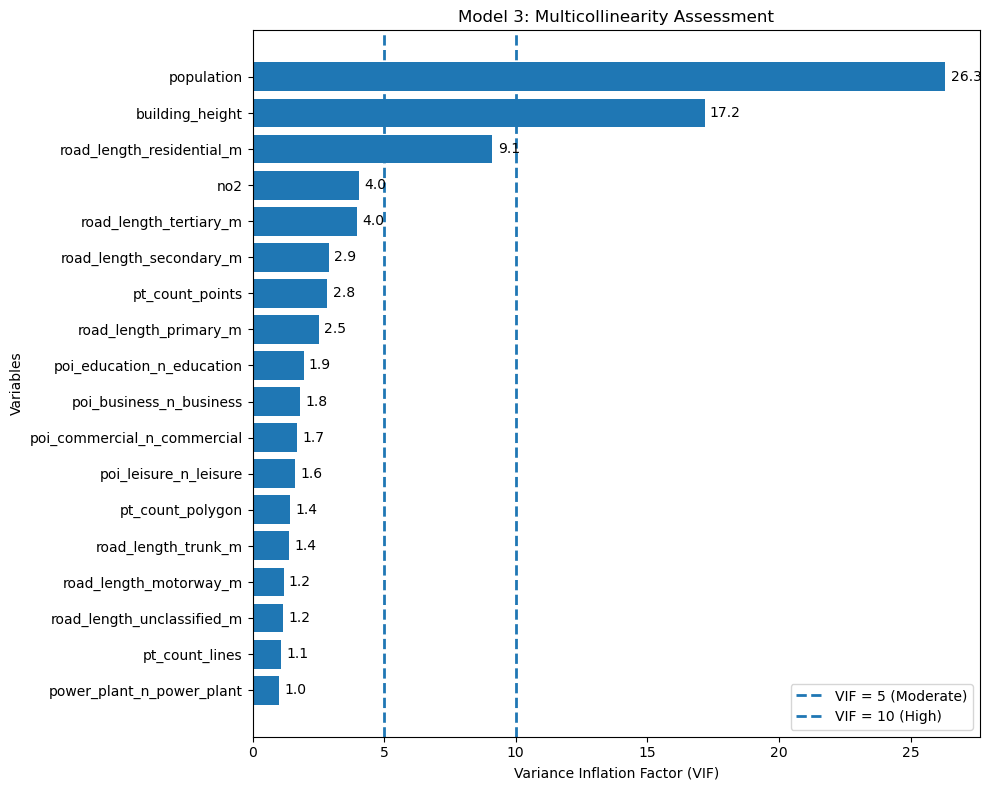

In [11]:
# ------------------------------------------------------------
# VIF BAR CHART - MODEL 3
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Copy dataframe
vif_plot = vif_m3.copy()

# Hapus intercept/constant kalau ada
vif_plot = vif_plot[
    ~vif_plot["Variable"].str.contains(
        "const",
        case=False,
        na=False
    )
]

# Urutkan
vif_plot = vif_plot.sort_values(
    "VIF",
    ascending=True
)

# Plot
plt.figure(
    figsize=(10,8)
)

bars = plt.barh(
    vif_plot["Variable"],
    vif_plot["VIF"]
)

# Threshold lines
plt.axvline(
    x=5,
    linestyle="--",
    linewidth=2,
    label="VIF = 5 (Moderate)"
)

plt.axvline(
    x=10,
    linestyle="--",
    linewidth=2,
    label="VIF = 10 (High)"
)

# Value labels
for i, value in enumerate(vif_plot["VIF"]):

    plt.text(
        value + 0.2,
        i,
        f"{value:.1f}",
        va="center"
    )

plt.xlabel(
    "Variance Inflation Factor (VIF)"
)

plt.ylabel(
    "Variables"
)

plt.title(
    "Model 3: Multicollinearity Assessment"
)

plt.legend()

plt.tight_layout()

plt.show()

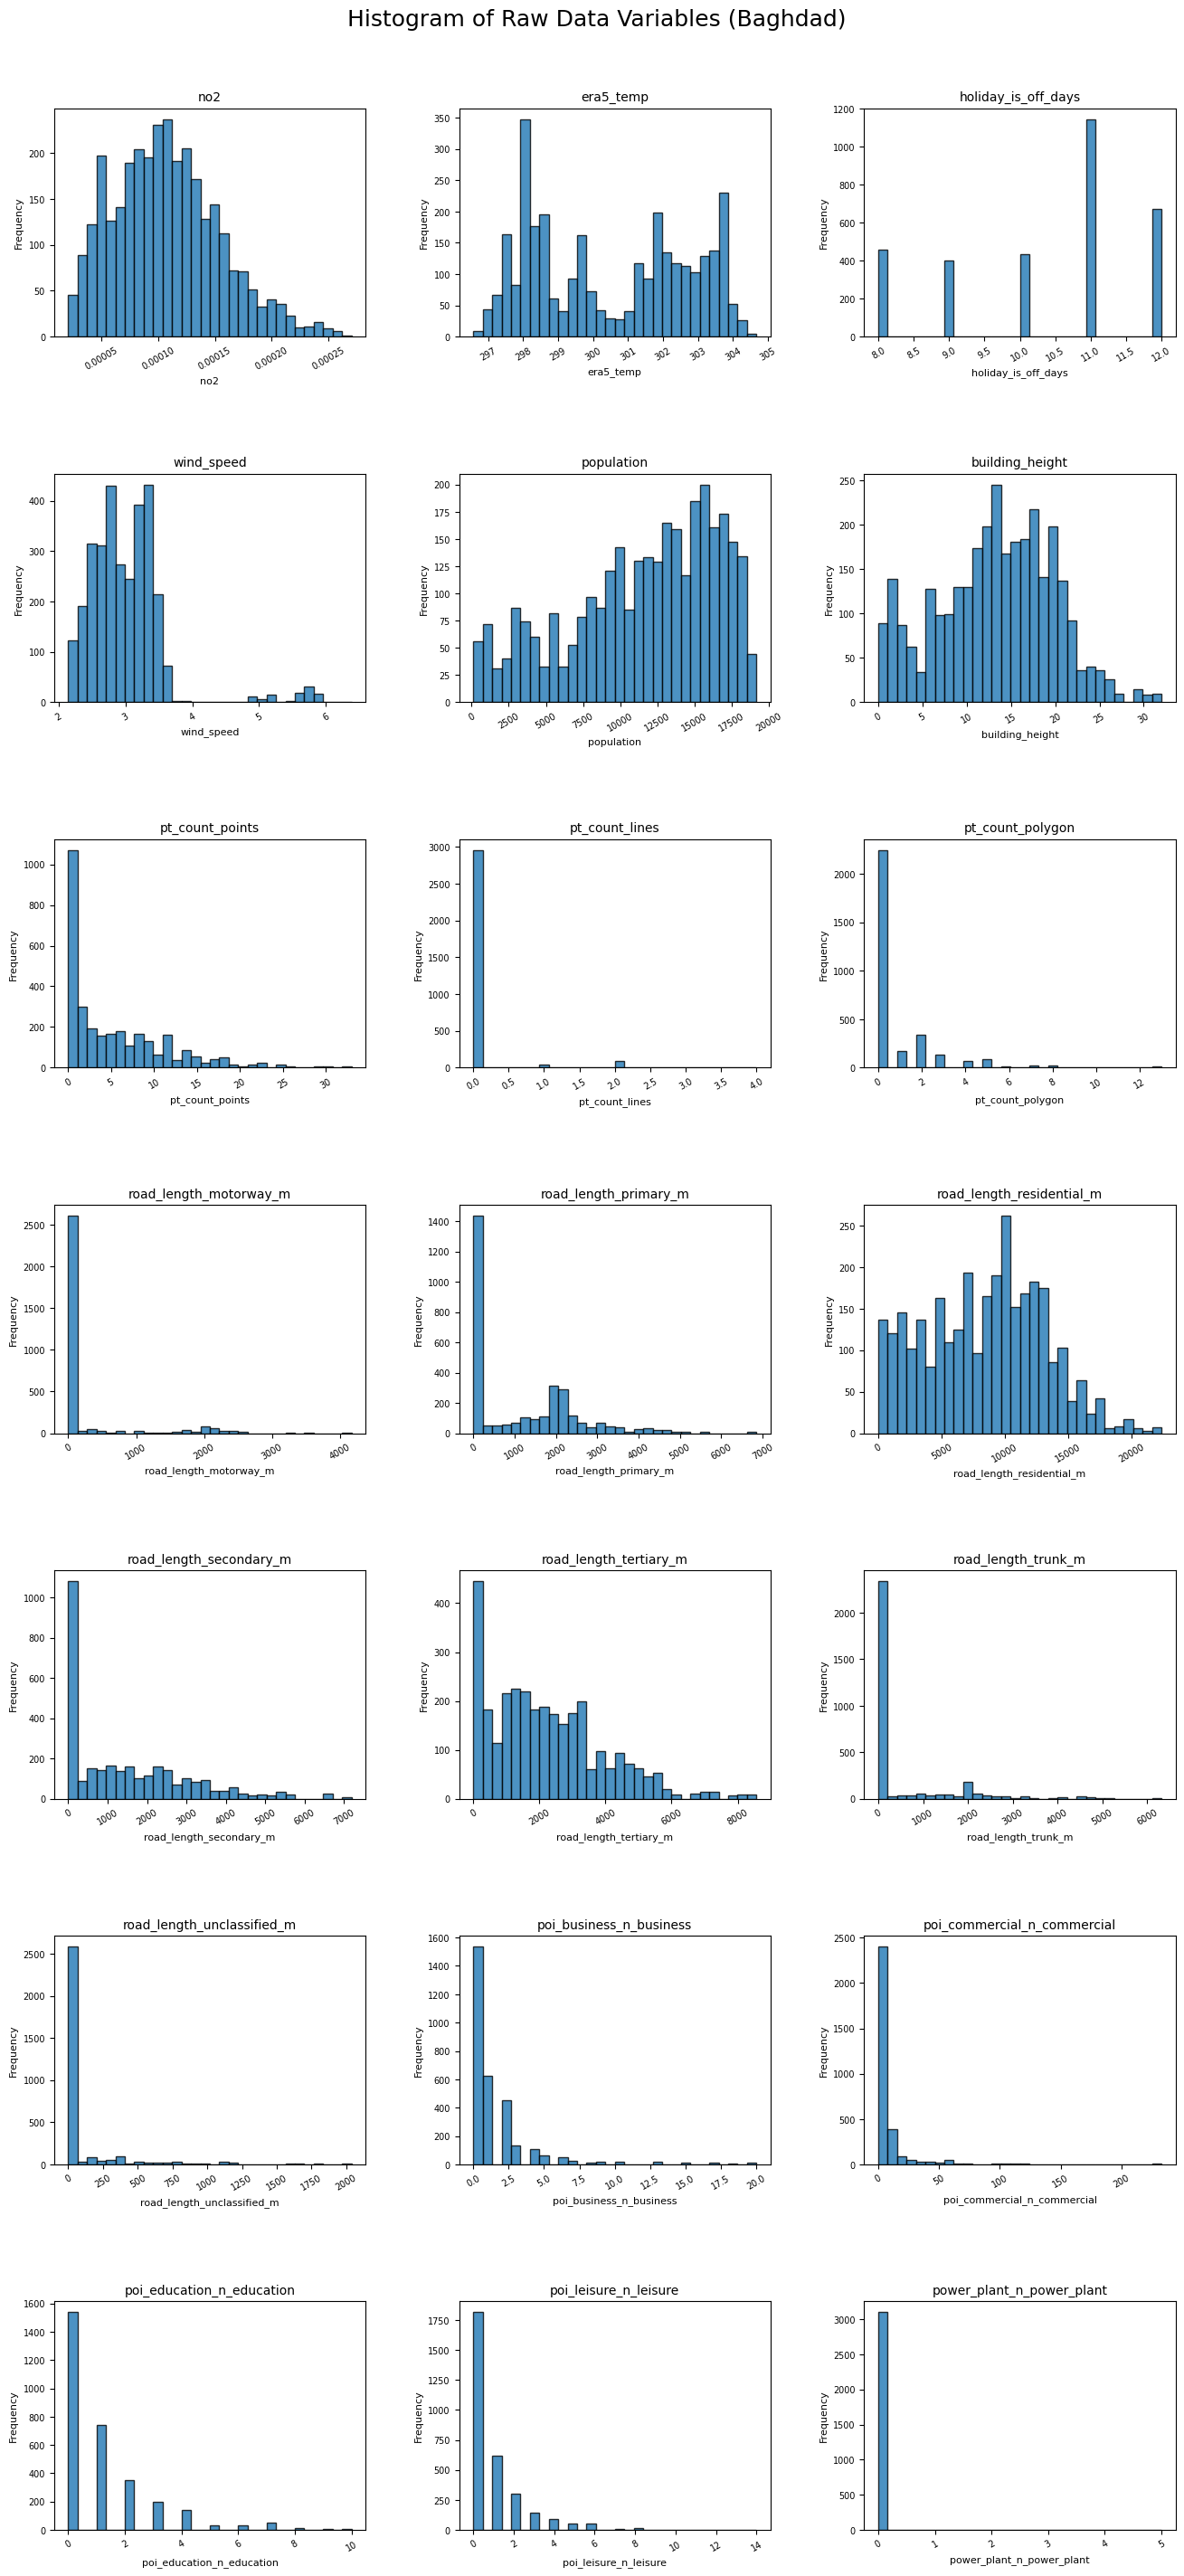

In [12]:
# ============================================================
# HISTOGRAM OF RAW DATA FOR ALL VARIABLES
# ============================================================

import matplotlib.pyplot as plt

variables = [
    "no2",
    "era5_temp",
    "holiday_is_off_days",
    "wind_speed",
    "population",
    "building_height",
    "pt_count_points",
    "pt_count_lines",
    "pt_count_polygon",
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
    "power_plant_n_power_plant"
]

ncols = 3
nrows = (len(variables) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.5 * nrows)
)

axes = axes.flatten()

for i, var in enumerate(variables):

    axes[i].hist(
        df[var].dropna(),
        bins=30,
        edgecolor="black",
        alpha=0.8
    )

    axes[i].set_title(
        var,
        fontsize=10
    )

    axes[i].set_xlabel(
        var,
        fontsize=8
    )

    axes[i].set_ylabel(
        "Frequency",
        fontsize=8
    )

    axes[i].tick_params(
        axis='x',
        labelsize=7,
        rotation=30
    )

    axes[i].tick_params(
        axis='y',
        labelsize=7
    )

# Remove empty axes
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Histogram of Raw Data Variables (Baghdad)",
    fontsize=18,
    y=0.995
)

plt.subplots_adjust(
    top=0.96,
    hspace=0.6,
    wspace=0.3
)

plt.show()

In [13]:
# ============================================================
# OLS FUNCTION
# ============================================================

def run_ols(
    data,
    y_var,
    x_vars,
    model_name
):

    print("\n")
    print("="*80)
    print(model_name)
    print("="*80)

    temp = clean_dataset(
        data,
        y_var,
        x_vars
    )

    X = temp[x_vars]

    X = sm.add_constant(
        X,
        has_constant="add"
    )

    y = temp[y_var]

    results = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HC3"
    )

    print(results.summary())

    print("\nGOODNESS OF FIT")
    print("-"*50)

    print("Observations :", int(results.nobs))
    print("R²           :", round(results.rsquared,4))
    print("Adj. R²      :", round(results.rsquared_adj,4))
    print("AIC          :", round(results.aic,2))
    print("BIC          :", round(results.bic,2))
    print("F-stat       :", round(results.fvalue,4))
    print("Prob(F)      :", results.f_pvalue)

    coef_table = pd.DataFrame({

        "Variable":
            results.params.index,

        "Coefficient":
            results.params.values,

        "Std_Error":
            results.bse.values,

        "t_stat":
            results.tvalues.values,

        "p_value":
            results.pvalues.values,

        "CI_Lower":
            results.conf_int()[0].values,

        "CI_Upper":
            results.conf_int()[1].values
    })

    print("\nCOEFFICIENTS")
    print("-"*50)

    print(coef_table)

    return results, coef_table

In [14]:
# ============================================================
# MONTH FIXED EFFECTS FUNCTION
# ============================================================

import statsmodels.formula.api as smf

def run_month_fe(
    data,
    y_var,
    x_vars,
    model_name
):

    print("\n")
    print("="*80)
    print(model_name)
    print("="*80)

    temp = clean_dataset(
        data,
        y_var,
        x_vars
    ).copy()

    temp["month"] = data.loc[
        temp.index,
        "month"
    ]

    formula = (
        y_var
        + " ~ "
        + " + ".join(x_vars)
        + " + C(month)"
    )

    results = smf.ols(
        formula=formula,
        data=temp
    ).fit(
        cov_type="HC3"
    )

    print(results.summary())

    coef_table = pd.DataFrame({

        "Variable": results.params.index,
        "Coefficient": results.params.values,
        "Std_Error": results.bse.values,
        "t_stat": results.tvalues.values,
        "p_value": results.pvalues.values,
        "CI_Lower": results.conf_int()[0].values,
        "CI_Upper": results.conf_int()[1].values

    })

    return results, coef_table

In [15]:
# ============================================================
# RUN OLS (PLAIN OLS + FE)
# ============================================================

results_m1, coef_m1 = run_ols(
    df,
    y_var,
    model1_vars,
    "MODEL 1: NO2 ONLY"
)

results_m2, coef_m2 = run_ols(
    df,
    y_var,
    model2_vars,
    "MODEL 2: ALL VARIABLES"
)

results_m3, coef_m3 = run_month_fe(
    df,
    y_var,
    model3_vars,
    "MODEL 3: EXCLUDING VARIABLES WITH HIGH MULTICOLINEARITY + MONTH FE"
)




MODEL 1: NO2 ONLY
                            OLS Regression Results                            
Dep. Variable:                    tci   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     18.63
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           1.64e-05
Time:                        13:56:15   Log-Likelihood:                -33899.
No. Observations:                3108   AIC:                         6.780e+04
Df Residuals:                    3106   BIC:                         6.781e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5470.3409    594.565

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 21, but rank is 15
  warnings.warn('covariance of constraints does not have full '
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 21
  warnings.warn('covariance of constraints does not have full '


In [16]:
# ============================================================
# Standardized Betas (Linear Form)
# ============================================================


def standardized_betas(
    data,
    y_var,
    x_vars
):

    temp = clean_dataset(
        data,
        y_var,
        x_vars
    )

    scaler = StandardScaler()

    X_std = pd.DataFrame(
        scaler.fit_transform(
            temp[x_vars]
        ),
        columns=x_vars
    )

    y_std = pd.Series(
        scaler.fit_transform(
            temp[[y_var]]
        ).flatten()
    )

    X_std = sm.add_constant(X_std)

    model = sm.OLS(
        y_std,
        X_std
    ).fit()

    betas = pd.DataFrame({

        "Variable":
            model.params.index,

        "Standardized_Beta":
            model.params.values
    })

    return betas

# Print Standardized Betas

print("\nMODEL 1")
print(
    standardized_betas(
        df,
        y_var,
        model1_vars
    )
)

print("\nMODEL 2")
print(
    standardized_betas(
        df,
        y_var,
        model2_vars
    )
)

print("\nMODEL 3")
print(
    standardized_betas(
        df,
        y_var,
        model3_vars
    )
)


MODEL 1
  Variable  Standardized_Beta
0    const       1.224702e-17
1      no2       9.466824e-02

MODEL 2
                       Variable  Standardized_Beta
0                         const       1.224702e-17
1                           no2       6.463757e-02
2                     era5_temp       1.028634e-02
3           holiday_is_off_days      -1.122172e-01
4                    wind_speed       8.164802e-02
5                    population       1.041894e-01
6               building_height      -1.553189e-01
7               pt_count_points       6.440683e-02
8                pt_count_lines      -2.836379e-02
9              pt_count_polygon      -2.614970e-02
10       road_length_motorway_m       3.461390e-01
11        road_length_primary_m       1.683087e-02
12    road_length_residential_m       6.742365e-02
13      road_length_secondary_m      -3.758143e-02
14       road_length_tertiary_m       8.145452e-02
15          road_length_trunk_m       2.359552e-01
16   road_length_unclassi

In [17]:
# ============================================================
# LOG TRANSFORMATION DATASET
# ============================================================

df_ols6 = df.copy()

# dependent variable
df_ols6["log_tci"] = np.log1p(df_ols6["tci"])

# NO2 transformation
df_ols6["log_no2"] = np.log(df_ols6["no2"] + 0.1)

In [18]:
cv_vars = [
    "population",
    "building_height",
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
    "pt_count_points",
    "pt_count_lines",
    "pt_count_polygon",
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
    "power_plant_n_power_plant"
]

In [19]:
# ------------------------------------------------------------
# STEP 1
# log(1+TCI) = log(0.1+NO2)
# ------------------------------------------------------------

step1_vars = ["log_no2"]

results_step1, coef_step1 = run_ols(
    df_ols6,
    y_var="log_tci",
    x_vars=step1_vars,
    model_name="STEP 1: NO2 ONLY"
)

adjr2_step1 = results_step1.rsquared_adj

print(
    "\nSTEP 1 Adj R²:",
    round(adjr2_step1, 4)
)



STEP 1: NO2 ONLY
                            OLS Regression Results                            
Dep. Variable:                log_tci   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     19.30
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           1.15e-05
Time:                        13:56:15   Log-Likelihood:                -4036.2
No. Observations:                3108   AIC:                             8076.
Df Residuals:                    3106   BIC:                             8089.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        384.5380     85.578 

In [20]:
# ------------------------------------------------------------
# STEP 2
# log(1+TCI) = log(0.1+NO2) + log(1+CV)
# ------------------------------------------------------------

# remove NO2 from control variables
cv_vars_step2 = [
    v for v in cv_vars
    if v != "no2"
]

# create log-transformed CVs
log_cv_vars = []

for v in cv_vars_step2:

    new_name = f"log_{v}"

    df_ols6[new_name] = np.log(
        df_ols6[v] + 1
    )

    log_cv_vars.append(new_name)

# NO2 only appears ONCE
step2_vars = ["log_no2"] + log_cv_vars

# safety check
print("Number of variables:", len(step2_vars))
print("Unique variables:", len(set(step2_vars)))

if len(step2_vars) != len(set(step2_vars)):
    raise ValueError(
        "Duplicate variables found in step2_vars"
    )

# run model
results_step2, coef_step2 = run_ols(
    data=df_ols6,
    y_var="log_tci",
    x_vars=step2_vars,
    model_name="STEP 2: LOG(CV)"
)

adjr2_step2 = results_step2.rsquared_adj

print(
    "\nSTEP 2 Adjusted R²:",
    round(adjr2_step2, 4)
)

Number of variables: 18
Unique variables: 18


STEP 2: LOG(CV)
                            OLS Regression Results                            
Dep. Variable:                log_tci   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     43.39
Date:                Tue, 23 Jun 2026   Prob (F-statistic):          1.46e-136
Time:                        13:56:15   Log-Likelihood:                -3624.6
No. Observations:                3108   AIC:                             7287.
Df Residuals:                    3089   BIC:                             7402.
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

In [21]:
# ------------------------------------------------------------
# STEP 3
# Choose best Adj R² model
# Add Month Fixed Effects
# ------------------------------------------------------------

if adjr2_step1 >= adjr2_step2:

    best_vars = step1_vars

    print(
        "\nBEST MODEL = STEP 1"
    )

else:

    best_vars = step2_vars

    print(
        "\nBEST MODEL = STEP 2"
    )

results_step3, coef_step3 = run_month_fe(
    data=df_ols6,
    y_var="log_tci",
    x_vars=best_vars,
    model_name=
    "STEP 3: BEST MODEL + MONTH FE"
)


BEST MODEL = STEP 2


STEP 3: BEST MODEL + MONTH FE
                            OLS Regression Results                            
Dep. Variable:                log_tci   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     41.28
Date:                Tue, 23 Jun 2026   Prob (F-statistic):          4.29e-195
Time:                        13:56:15   Log-Likelihood:                -3461.8
No. Observations:                3108   AIC:                             6984.
Df Residuals:                    3078   BIC:                             7165.
Df Model:                          29                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [22]:
# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

summary_table = pd.DataFrame({

    "Model":[
        "Step 1",
        "Step 2",
        "Step 3"
    ],

    "Adj_R2":[

        results_step1.rsquared_adj,

        results_step2.rsquared_adj,

        results_step3.rsquared_adj

    ]

})

summary_table = summary_table.sort_values(
    "Adj_R2",
    ascending=False
)

summary_table

,Model,Adj_R2
2,Step 3,0.307632
1,Step 2,0.233900
0,Step 1,0.007050


In [23]:
# ============================================================
# STANDARDIZED BETAS (LOG FORM)
# ============================================================

def standardized_betas(
    data,
    y_var,
    x_vars
):

    temp = clean_dataset(
        data,
        y_var,
        x_vars
    )

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_std = pd.DataFrame(
        scaler_x.fit_transform(
            temp[x_vars]
        ),
        columns=x_vars
    )

    y_std = scaler_y.fit_transform(
        temp[[y_var]]
    ).flatten()

    X_std = sm.add_constant(X_std)

    model = sm.OLS(
        y_std,
        X_std
    ).fit()

    betas = pd.DataFrame({

        "Variable":
            model.params.index,

        "Standardized_Beta":
            model.params.values

    })

    # remove intercept
    betas = betas[
        betas["Variable"] != "const"
    ]

    # sort by absolute beta
    betas["Abs_Beta"] = (
        betas["Standardized_Beta"]
        .abs()
    )

    betas = betas.sort_values(
        "Abs_Beta",
        ascending=False
    )

    return betas.drop(
        columns="Abs_Beta"
    )

In [24]:
print("\n" + "="*60)
print("STEP 1")
print("="*60)

beta_step1 = standardized_betas(
    df_ols6,
    "log_tci",
    step1_vars
)

print(beta_step1)

print(
    "\nStrongest Predictor:",
    beta_step1.iloc[0]["Variable"]
)

print(
    "Standardized Beta:",
    round(
        beta_step1.iloc[0]["Standardized_Beta"],
        3
    )
)


STEP 1
  Variable  Standardized_Beta
1  log_no2           0.085847

Strongest Predictor: log_no2
Standardized Beta: 0.086


In [25]:
print("\n" + "="*60)
print("STEP 2")
print("="*60)

beta_step2 = standardized_betas(
    df_ols6,
    "log_tci",
    step2_vars
)

print(beta_step2)

print(
    "\nStrongest Predictor:",
    beta_step2.iloc[0]["Variable"]
)

print(
    "Standardized Beta:",
    round(
        beta_step2.iloc[0]["Standardized_Beta"],
        3
    )
)


STEP 2
                           Variable  Standardized_Beta
4        log_road_length_motorway_m           0.320217
9           log_road_length_trunk_m           0.304406
16    log_poi_education_n_education          -0.149231
8        log_road_length_tertiary_m           0.110696
3               log_building_height          -0.107468
11              log_pt_count_points           0.091770
1                           log_no2           0.068479
6     log_road_length_residential_m           0.067533
17        log_poi_leisure_n_leisure          -0.061845
18    log_power_plant_n_power_plant          -0.044119
12               log_pt_count_lines          -0.041853
2                    log_population           0.036567
14      log_poi_business_n_business           0.024680
7       log_road_length_secondary_m          -0.023242
13             log_pt_count_polygon          -0.018510
5         log_road_length_primary_m           0.013527
10   log_road_length_unclassified_m           0.009093
15

In [26]:
print("\n" + "="*60)
print("STEP 3")
print("="*60)

beta_step3 = standardized_betas(
    df_ols6,
    "log_tci",
    best_vars
)

print(beta_step3)

print(
    "\nStrongest Predictor:",
    beta_step3.iloc[0]["Variable"]
)

print(
    "Standardized Beta:",
    round(
        beta_step3.iloc[0]["Standardized_Beta"],
        3
    )
)


STEP 3
                           Variable  Standardized_Beta
4        log_road_length_motorway_m           0.320217
9           log_road_length_trunk_m           0.304406
16    log_poi_education_n_education          -0.149231
8        log_road_length_tertiary_m           0.110696
3               log_building_height          -0.107468
11              log_pt_count_points           0.091770
1                           log_no2           0.068479
6     log_road_length_residential_m           0.067533
17        log_poi_leisure_n_leisure          -0.061845
18    log_power_plant_n_power_plant          -0.044119
12               log_pt_count_lines          -0.041853
2                    log_population           0.036567
14      log_poi_business_n_business           0.024680
7       log_road_length_secondary_m          -0.023242
13             log_pt_count_polygon          -0.018510
5         log_road_length_primary_m           0.013527
10   log_road_length_unclassified_m           0.009093
15

In [27]:
# ============================================================
# Model Comparison
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Model1(LIN)",
        "Model2(LIN)",
        "Model3(LIN)",
        "Model1(LOG)",
        "Model2(LOG)",
        "Model3(LOG)",
    ],

    "R2": [
        results_m1.rsquared,
        results_m2.rsquared,
        results_m3.rsquared,
        results_step1.rsquared,
        results_step2.rsquared,
        results_step3.rsquared,
    ],

    "Adj_R2": [
        results_m1.rsquared_adj,
        results_m2.rsquared_adj,
        results_m3.rsquared_adj,
        results_step1.rsquared,
        results_step2.rsquared,
        results_step3.rsquared,
    ],

    "AIC": [
        results_m1.aic,
        results_m2.aic,
        results_m3.aic,
        results_step1.rsquared,
        results_step2.rsquared,
        results_step3.rsquared,
    ],

    "BIC": [
        results_m1.bic,
        results_m2.bic,
        results_m3.bic,
        results_step1.rsquared,
        results_step2.rsquared,
        results_step3.rsquared,
    ]
})

print(comparison)

         Model        R2    Adj_R2           AIC           BIC
0  Model1(LIN)  0.008962  0.008643  67801.220394  67813.303864
1  Model2(LIN)  0.242144  0.236987  67007.470441  67140.388605
2  Model3(LIN)  0.254976  0.247957  66970.394880  67151.646921
3  Model1(LOG)  0.007370  0.007370      0.007370      0.007370
4  Model2(LOG)  0.238338  0.238338      0.238338      0.238338
5  Model3(LOG)  0.314094  0.314094      0.314094      0.314094


In [28]:
# ============================================================
# Prediction Function (LINEAR MODEL)
# ============================================================

def predictive_evaluation(
    data,
    y_var,
    x_vars,
    model_name
):

    temp = clean_dataset(
        data,
        y_var,
        x_vars
    )

    X = temp[x_vars]

    y = temp[y_var]

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            random_state=42
        )
    )

    lr = LinearRegression()

    lr.fit(
        X_train,
        y_train
    )

    pred_train = lr.predict(
        X_train
    )

    pred_test = lr.predict(
        X_test
    )

    results = {

        "Model":
            model_name,

        "Train_R2":
            r2_score(
                y_train,
                pred_train
            ),

        "Test_R2":
            r2_score(
                y_test,
                pred_test
            ),

        "Train_RMSE":
            np.sqrt(
                mean_squared_error(
                    y_train,
                    pred_train
                )
            ),

        "Test_RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred_test
                )
            )
    }

    return results


In [29]:
# ------------------------------------------------------------
# Run Predictive Models
# ------------------------------------------------------------


pred_m1 = predictive_evaluation(
    df,
    y_var,
    model1_vars,
    "Model1"
)

pred_m2 = predictive_evaluation(
    df,
    y_var,
    model2_vars,
    "Model2"
)

pred_m3 = predictive_evaluation(
    df,
    y_var,
    model3_vars,
    "Model3"
)



In [30]:
# ------------------------------------------------------------
# Prediction Comparison
# ------------------------------------------------------------

prediction_results = pd.DataFrame([
    pred_m1,
    pred_m2,
    pred_m3
])

prediction_results

,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE
0,Model1,0.011801,-0.001815,12880.556270,14410.230526
1,Model2,0.261710,0.172337,11133.347608,13097.971445
2,Model3,0.246361,0.142995,11248.483291,13328.119050


In [31]:
# ============================================================
# RIDGE REGRESSION FUNCTION
# ============================================================

from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

def run_ridge(
    data,
    y_var,
    x_vars,
    model_name
):

    print("\n")
    print("="*80)
    print(model_name)
    print("="*80)

    temp = clean_dataset(
        data,
        y_var,
        x_vars
    )

    X = temp[x_vars]
    y = temp[y_var]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(
            alphas=np.logspace(-3,3,100)
        ))
    ])

    pipeline.fit(X, y)

    pred = pipeline.predict(X)

    ridge = pipeline.named_steps["ridge"]

    coef_table = pd.DataFrame({
        "Variable": x_vars,
        "Coefficient": ridge.coef_
    })

    coef_table["Abs_Coefficient"] = (
        coef_table["Coefficient"].abs()
    )

    coef_table = coef_table.sort_values(
        "Abs_Coefficient",
        ascending=False
    )

    print("\nGOODNESS OF FIT")
    print("-"*50)
    print("Best Alpha :", round(ridge.alpha_,4))
    print("R²         :", round(r2_score(y,pred),4))
    print(
        "RMSE       :",
        round(
            np.sqrt(
                mean_squared_error(
                    y,
                    pred
                )
            ),
            4
        )
    )

    display(coef_table)

    return ridge, coef_table

In [32]:
# ============================================================
# RUN RIDGE MODELS (LINEAR)
# ============================================================

ridge_m1, ridge_coef_m1 = run_ridge(
    df,
    y_var,
    model1_vars,
    "RIDGE MODEL 1"
)

ridge_m2, ridge_coef_m2 = run_ridge(
    df,
    y_var,
    model2_vars,
    "RIDGE MODEL 2"
)

ridge_m3, ridge_coef_m3 = run_ridge(
    df,
    y_var,
    model3_vars,
    "RIDGE MODEL 3"
)



RIDGE MODEL 1

GOODNESS OF FIT
--------------------------------------------------
Best Alpha : 187.3817
R²         : 0.0089
RMSE       : 13199.9038


,Variable,Coefficient,Abs_Coefficient
0,no2,1183.855978,1183.855978




RIDGE MODEL 2

GOODNESS OF FIT
--------------------------------------------------
Best Alpha : 61.3591
R²         : 0.242
RMSE       : 11544.0389


,Variable,Coefficient,Abs_Coefficient
9,road_length_motorway_m,4498.779788,4498.779788
14,road_length_trunk_m,3062.622609,3062.622609
5,building_height,-1880.856877,1880.856877
18,poi_education_n_education,-1476.164819,1476.164819
2,holiday_is_off_days,-1438.429957,1438.429957
4,population,1259.876701,1259.876701
3,wind_speed,1067.904503,1067.904503
13,road_length_tertiary_m,1057.780028,1057.780028
11,road_length_residential_m,853.569114,853.569114
6,pt_count_points,837.449563,837.449563




RIDGE MODEL 3

GOODNESS OF FIT
--------------------------------------------------
Best Alpha : 61.3591
R²         : 0.2229
RMSE       : 11688.6344


,Variable,Coefficient,Abs_Coefficient
6,road_length_motorway_m,4593.316302,4593.316302
11,road_length_trunk_m,3061.172402,3061.172402
2,building_height,-1721.030424,1721.030424
15,poi_education_n_education,-1452.175120,1452.175120
1,population,1171.502868,1171.502868
10,road_length_tertiary_m,1033.447712,1033.447712
0,no2,961.986970,961.986970
8,road_length_residential_m,878.544211,878.544211
13,poi_business_n_business,845.229756,845.229756
3,pt_count_points,706.962194,706.962194


In [33]:
# ============================================================
# LASSO FUNCTION
# ============================================================

from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

def run_lasso(
    data,
    y_var,
    x_vars,
    model_name
):

    print("\n")
    print("="*80)
    print(model_name)
    print("="*80)

    temp = clean_dataset(
        data,
        y_var,
        x_vars
    )

    X = temp[x_vars]
    y = temp[y_var]

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "lasso",
            LassoCV(
                cv=5,
                random_state=42,
                max_iter=10000
            )
        )
    ])

    model.fit(X, y)

    y_pred = model.predict(X)

    lasso = model.named_steps["lasso"]

    coef_table = pd.DataFrame({
        "Variable": x_vars,
        "Coefficient": lasso.coef_
    })

    coef_table["AbsCoef"] = (
        coef_table["Coefficient"].abs()
    )

    coef_table = coef_table.sort_values(
        "AbsCoef",
        ascending=False
    )

    print(
        "Best alpha:",
        round(
            lasso.alpha_,
            4
        )
    )

    print(
        "R²:",
        round(
            r2_score(
                y,
                y_pred
            ),
            4
        )
    )

    print(
        "RMSE:",
        round(
            np.sqrt(
                mean_squared_error(
                    y,
                    y_pred
                )
            ),
            4
        )
    )

    display(
        coef_table[
            ["Variable", "Coefficient"]
        ]
    )

    return lasso, coef_table

In [34]:
# ============================================================
# RUN LASSO MODELS (LOG FORM)
# ============================================================

lasso_step1, lasso_coef_step1 = run_lasso(
    df_ols6,
    "log_tci",
    step1_vars,
    "LASSO STEP 1"
)

lasso_step2, lasso_coef_step2 = run_lasso(
    df_ols6,
    "log_tci",
    step2_vars,
    "LASSO STEP 2"
)

lasso_step3, lasso_coef_step3 = run_lasso(
    df_ols6,
    "log_tci",
    best_vars,
    "LASSO STEP 3"
)



LASSO STEP 1
Best alpha: 0.0154
R²: 0.0071
RMSE: 0.8868


,Variable,Coefficient
0,log_no2,0.061049




LASSO STEP 2
Best alpha: 0.0171
R²: 0.231
RMSE: 0.7804


,Variable,Coefficient
3,log_road_length_motorway_m,0.264786
8,log_road_length_trunk_m,0.255009
15,log_poi_education_n_education,-0.109908
7,log_road_length_tertiary_m,0.074100
10,log_pt_count_points,0.056562
0,log_no2,0.042468
16,log_poi_leisure_n_leisure,-0.041202
17,log_power_plant_n_power_plant,-0.030418
11,log_pt_count_lines,-0.018929
5,log_road_length_residential_m,0.016066




LASSO STEP 3
Best alpha: 0.0171
R²: 0.231
RMSE: 0.7804


,Variable,Coefficient
3,log_road_length_motorway_m,0.264786
8,log_road_length_trunk_m,0.255009
15,log_poi_education_n_education,-0.109908
7,log_road_length_tertiary_m,0.074100
10,log_pt_count_points,0.056562
0,log_no2,0.042468
16,log_poi_leisure_n_leisure,-0.041202
17,log_power_plant_n_power_plant,-0.030418
11,log_pt_count_lines,-0.018929
5,log_road_length_residential_m,0.016066


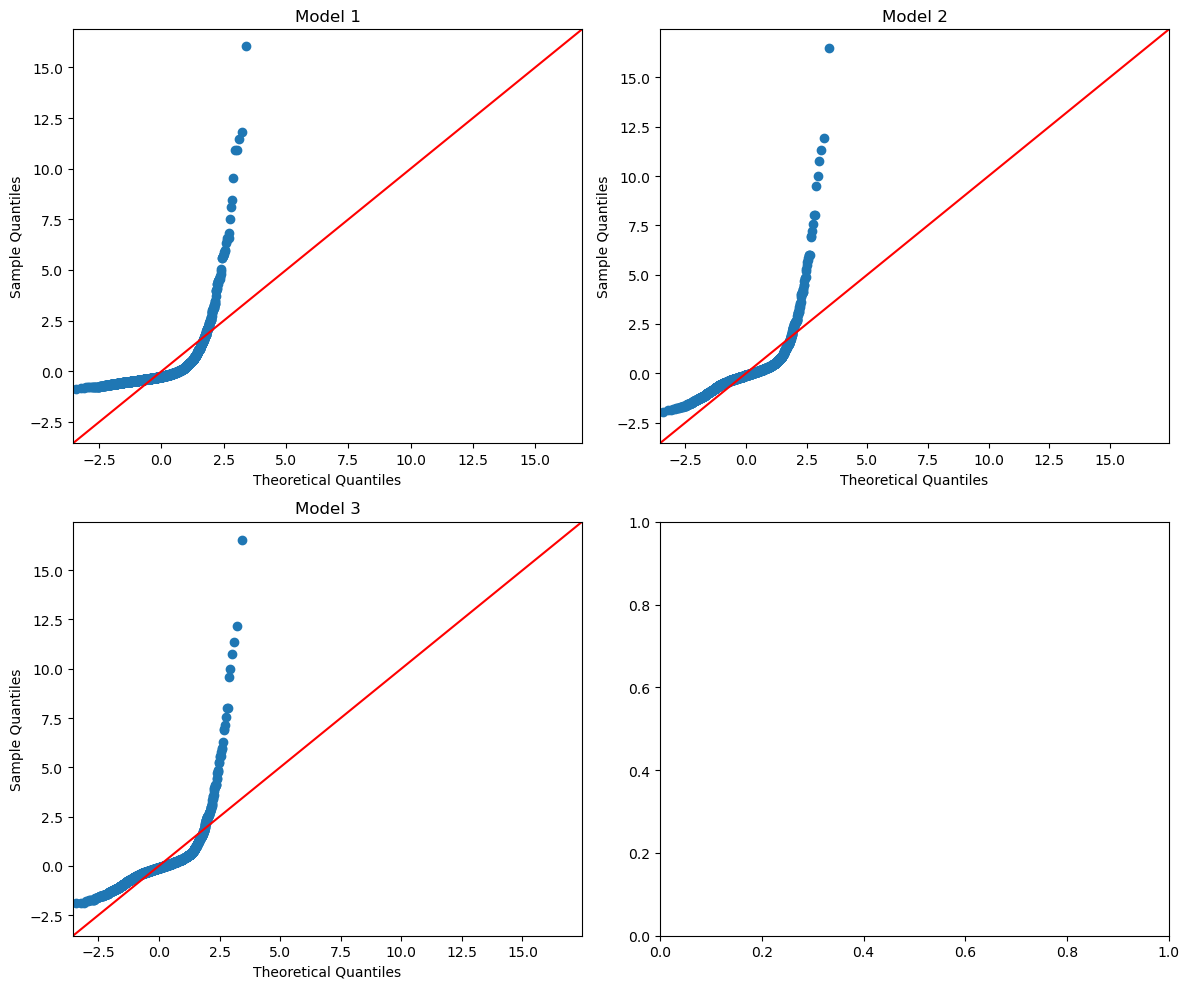

In [35]:
# ============================================================
# QQ PLOTS OF OLS RESIDUALS (LIN FORM)
# ============================================================

import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

for ax, (title, result) in zip(axes.flatten(), models.items()):

    sm.qqplot(
        result.resid,
        line="45",
        fit=True,
        ax=ax
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

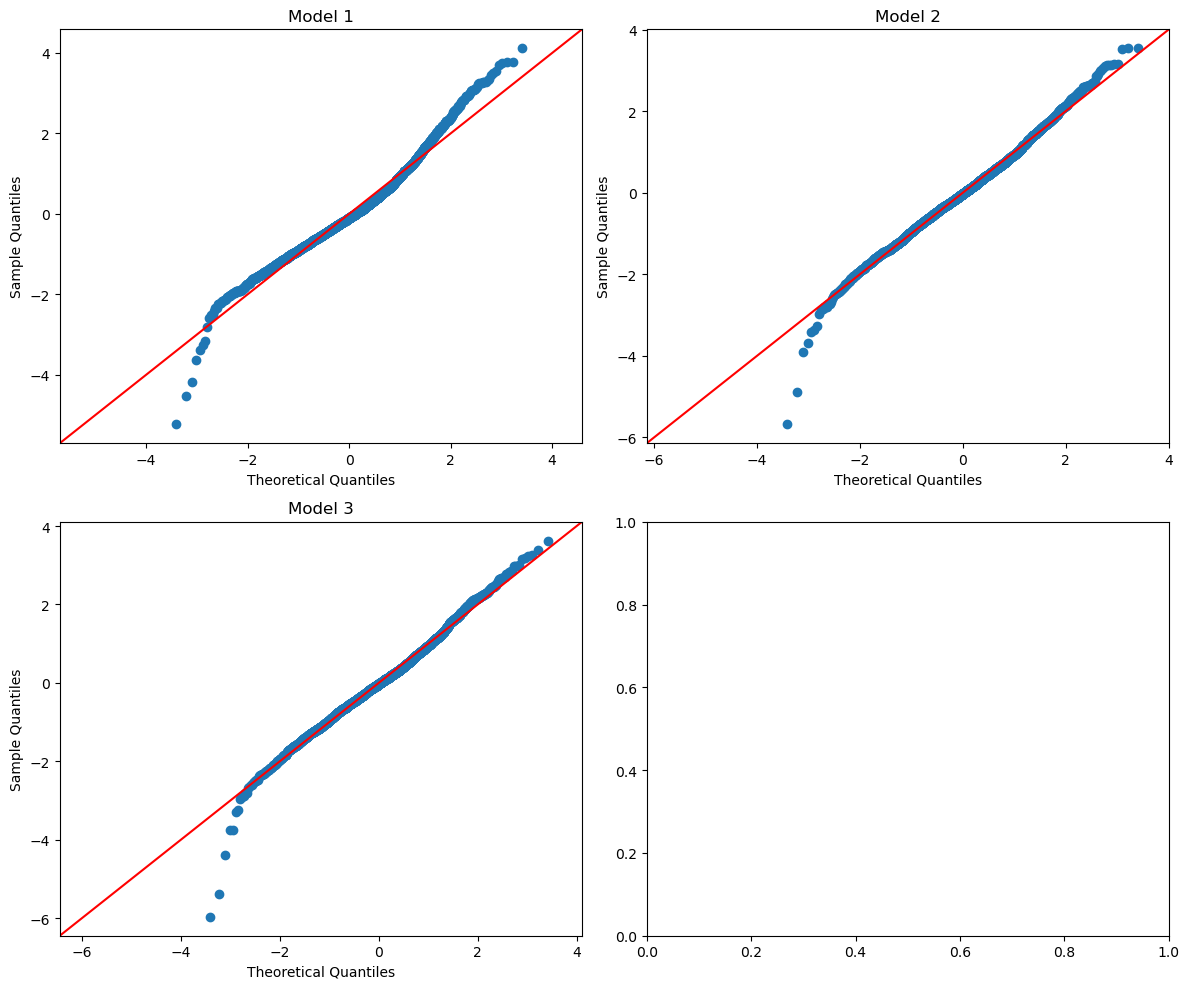

In [36]:
# ============================================================
# QQ PLOTS OF OLS RESIDUALS (LOG FORM)
# ============================================================

import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = {
    "Model 1": results_step1,
    "Model 2": results_step2,
    "Model 3": results_step3
}

for ax, (title, result) in zip(axes.flatten(), models.items()):

    sm.qqplot(
        result.resid,
        line="45",
        fit=True,
        ax=ax
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

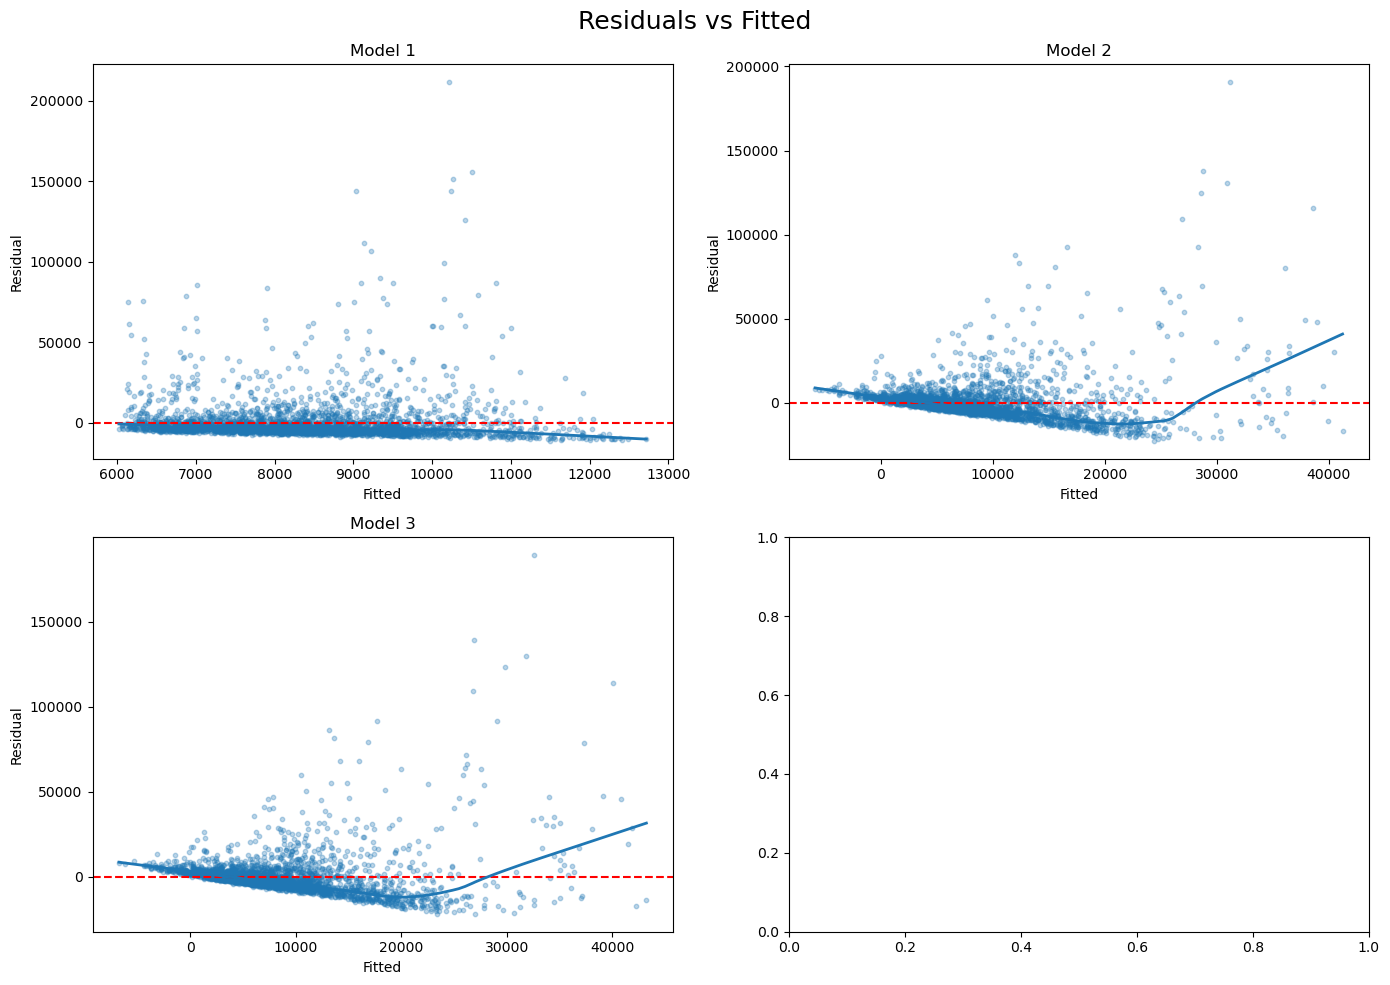

In [37]:
# ============================================================
# RESIDUALS VS FITTED (LIN FORM)
# ============================================================

import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    fitted = result.fittedvalues
    resid = result.resid

    ax.scatter(
        fitted,
        resid,
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color='red',
        linestyle='--'
    )

    smooth = lowess(
        resid,
        fitted,
        frac=0.1
    )

    ax.plot(
        smooth[:,0],
        smooth[:,1],
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel("Fitted")
    ax.set_ylabel("Residual")

plt.suptitle(
    "Residuals vs Fitted",
    fontsize=18
)

plt.tight_layout()
plt.show()

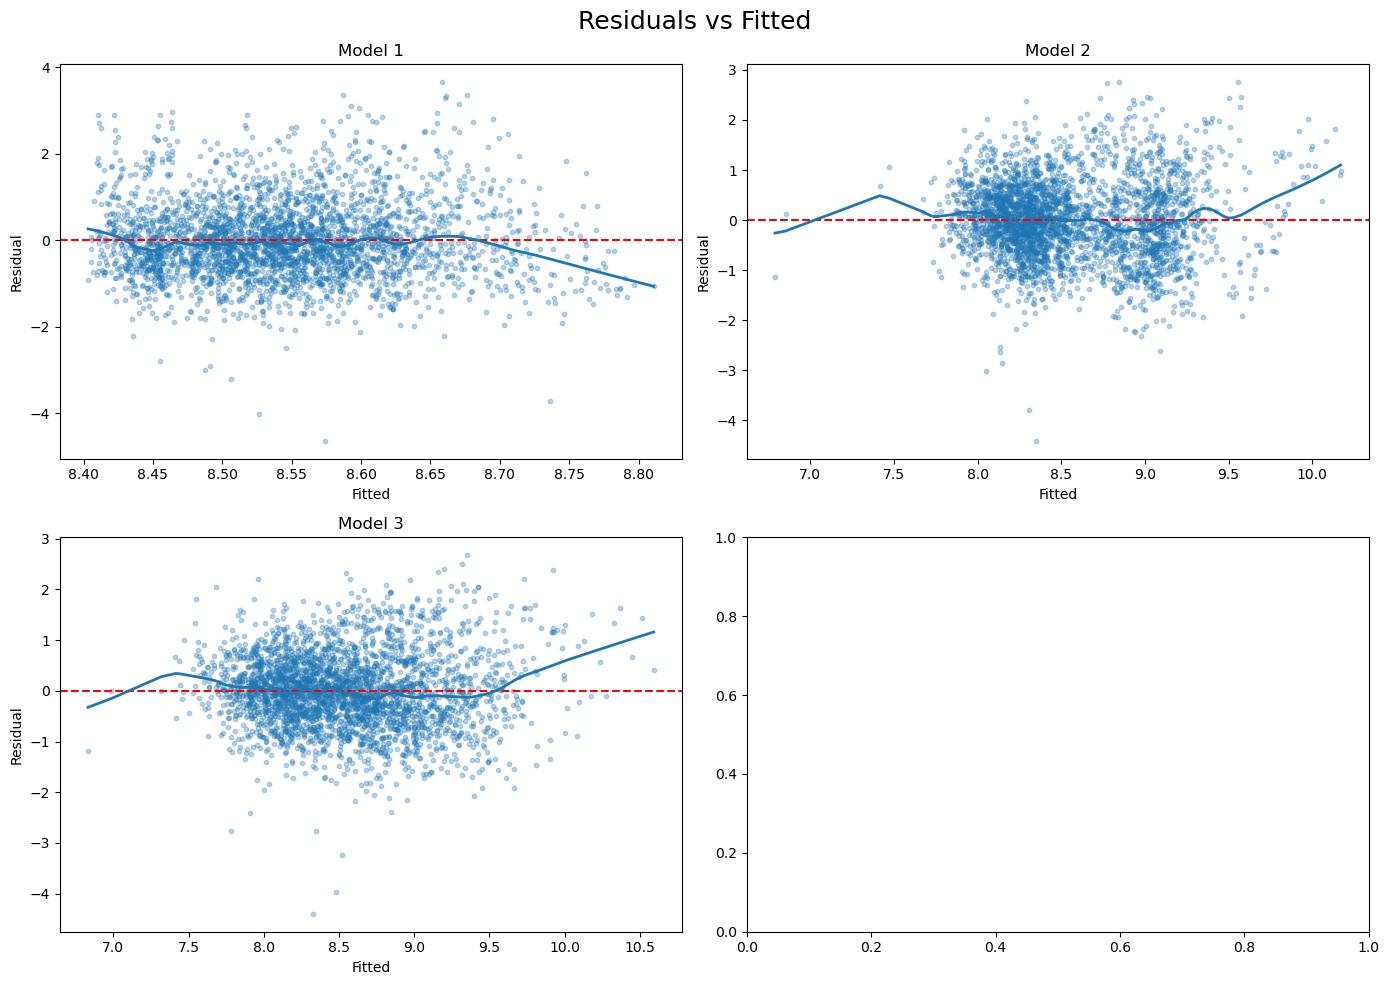

In [38]:
# ============================================================
# RESIDUALS VS FITTED (LOG FORM)
# ============================================================

import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

models = {
    "Model 1": results_step1,
    "Model 2": results_step2,
    "Model 3": results_step3
}

fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    fitted = result.fittedvalues
    resid = result.resid

    ax.scatter(
        fitted,
        resid,
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color='red',
        linestyle='--'
    )

    smooth = lowess(
        resid,
        fitted,
        frac=0.1
    )

    ax.plot(
        smooth[:,0],
        smooth[:,1],
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel("Fitted")
    ax.set_ylabel("Residual")

plt.suptitle(
    "Residuals vs Fitted",
    fontsize=18
)

plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


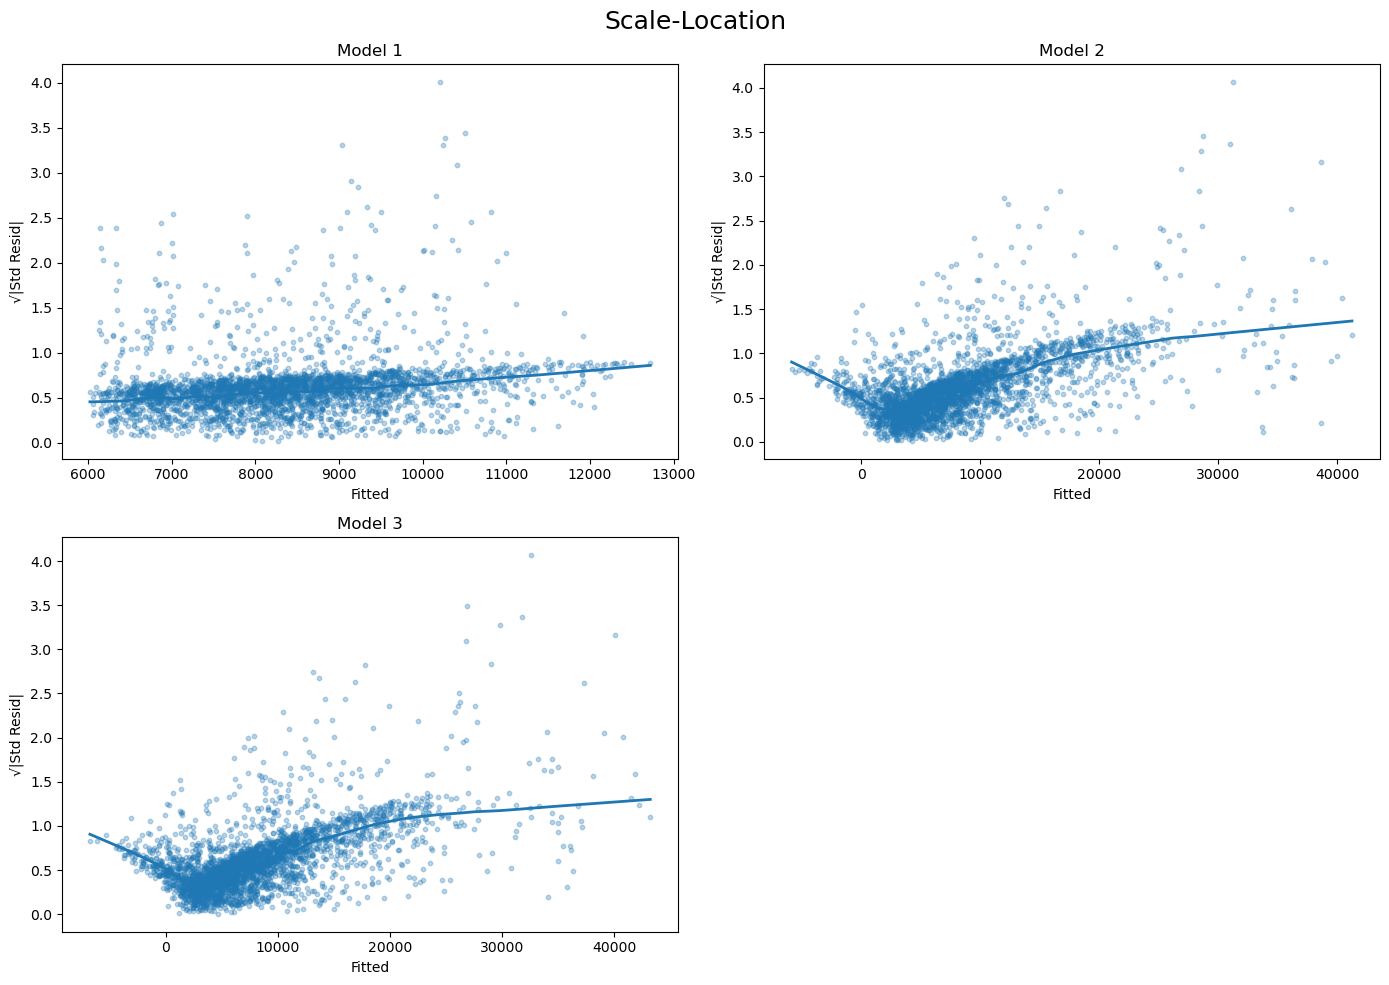

In [39]:
# ============================================================
# SCALE-LOCATION (LIN FORM)
# ============================================================

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    influence = result.get_influence()

    fitted = result.fittedvalues

    std_resid = influence.resid_studentized_internal

    y = np.sqrt(np.abs(std_resid))

    ax.scatter(
        fitted,
        y,
        alpha=0.3,
        s=10
    )

    smooth = lowess(
        y,
        fitted,
        frac=0.1
    )

    ax.plot(
        smooth[:,0],
        smooth[:,1],
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel("Fitted")
    ax.set_ylabel("√|Std Resid|")

# hilangkan panel kosong
axes[1,1].axis("off")

plt.suptitle(
    "Scale-Location",
    fontsize=18
)

plt.tight_layout()
plt.show()

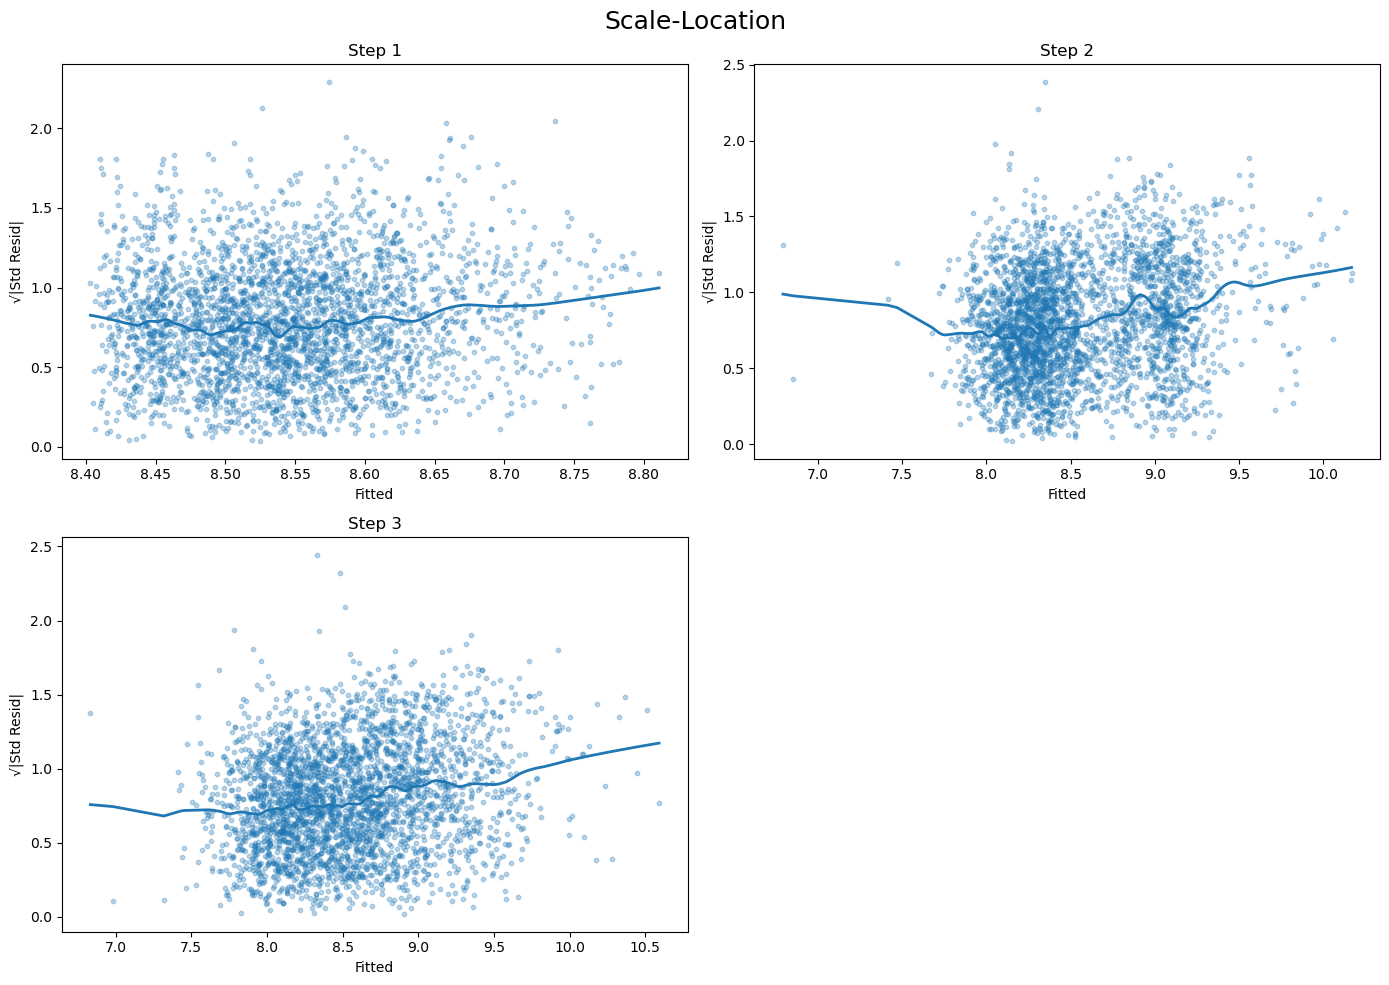

In [40]:
# ============================================================
# SCALE-LOCATION (LOG FORM)
# ============================================================

models = {
    "Step 1": results_step1,
    "Step 2": results_step2,
    "Step 3": results_step3
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    influence = result.get_influence()

    fitted = result.fittedvalues

    std_resid = influence.resid_studentized_internal

    y = np.sqrt(np.abs(std_resid))

    ax.scatter(
        fitted,
        y,
        alpha=0.3,
        s=10
    )

    smooth = lowess(
        y,
        fitted,
        frac=0.1
    )

    ax.plot(
        smooth[:,0],
        smooth[:,1],
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel("Fitted")
    ax.set_ylabel("√|Std Resid|")

axes[1,1].axis("off")

plt.suptitle(
    "Scale-Location",
    fontsize=18
)

plt.tight_layout()
plt.show()

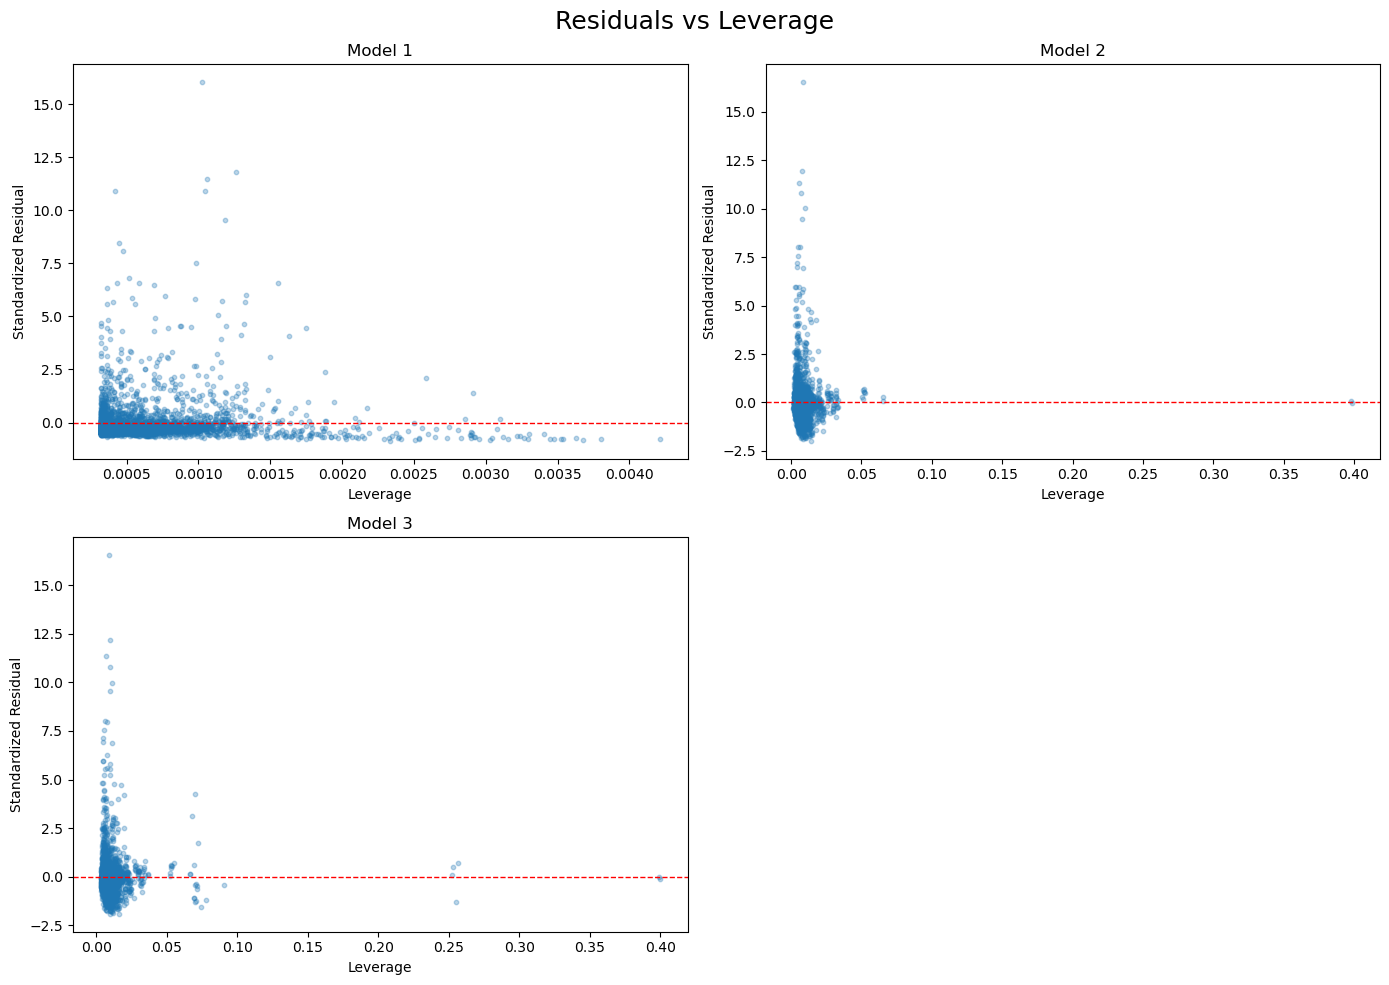

In [41]:
# ============================================================
# RESIDUALS VS LEVERAGE (LIN FORM)
# ============================================================

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    influence = result.get_influence()

    leverage = influence.hat_matrix_diag

    std_resid = influence.resid_studentized_internal

    ax.scatter(
        leverage,
        std_resid,
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color='red',
        linestyle='--',
        linewidth=1
    )

    ax.set_title(name)
    ax.set_xlabel("Leverage")
    ax.set_ylabel("Standardized Residual")

# hilangkan panel kosong
axes[1,1].axis("off")

plt.suptitle(
    "Residuals vs Leverage",
    fontsize=18
)

plt.tight_layout()
plt.show()

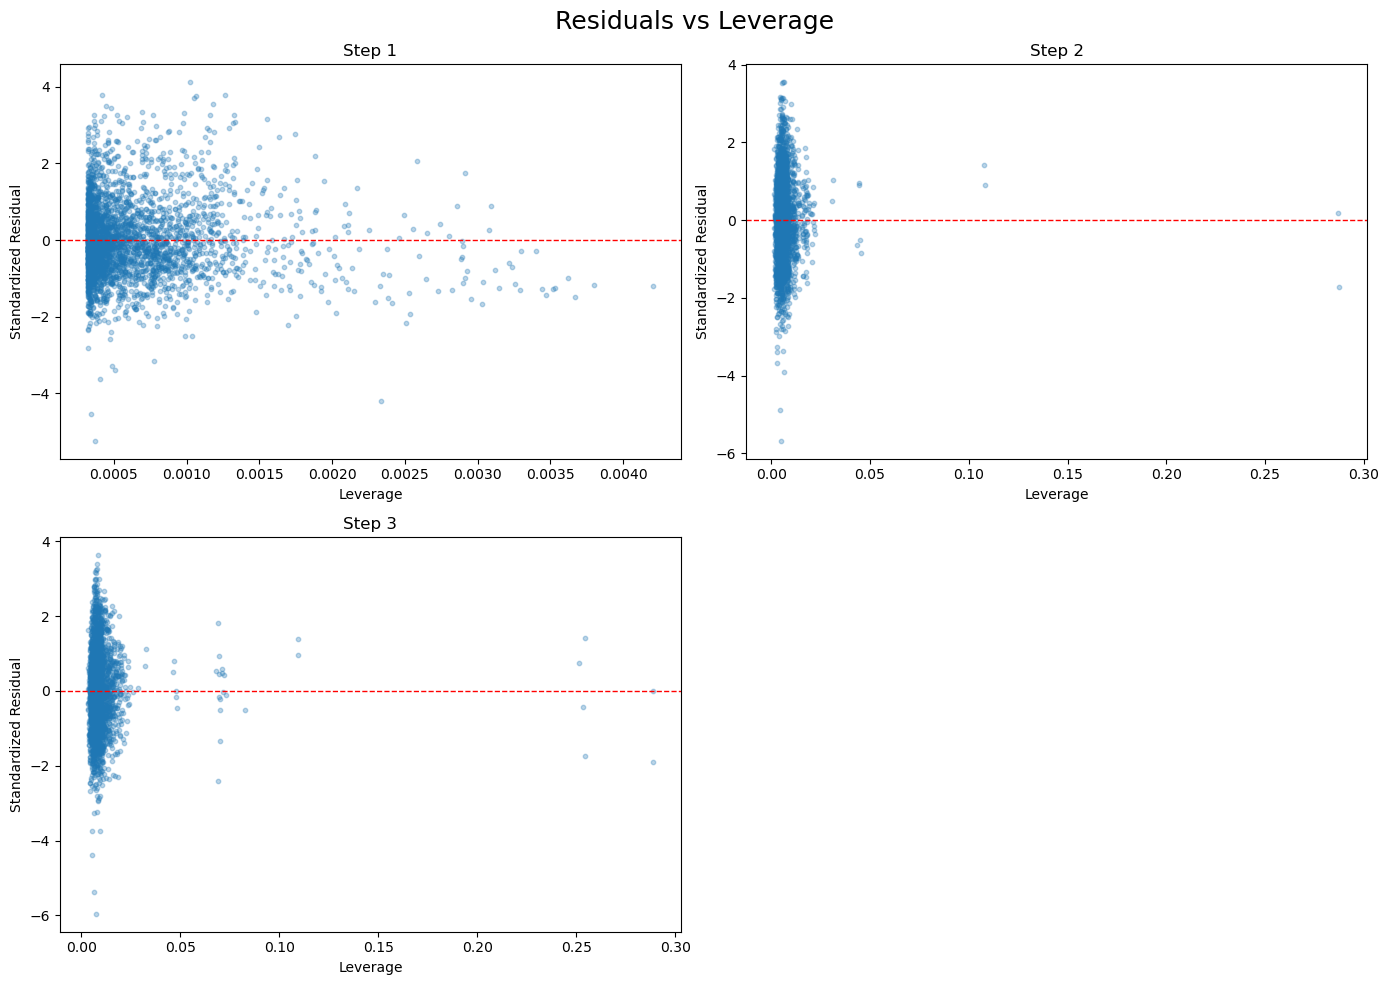

In [42]:
# ============================================================
# RESIDUALS VS LEVERAGE (LOG FORM)
# ============================================================

models = {
    "Step 1": results_step1,
    "Step 2": results_step2,
    "Step 3": results_step3
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    influence = result.get_influence()

    leverage = influence.hat_matrix_diag

    std_resid = influence.resid_studentized_internal

    ax.scatter(
        leverage,
        std_resid,
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color='red',
        linestyle='--',
        linewidth=1
    )

    ax.set_title(name)
    ax.set_xlabel("Leverage")
    ax.set_ylabel("Standardized Residual")

axes[1,1].axis("off")

plt.suptitle(
    "Residuals vs Leverage",
    fontsize=18
)

plt.tight_layout()
plt.show()

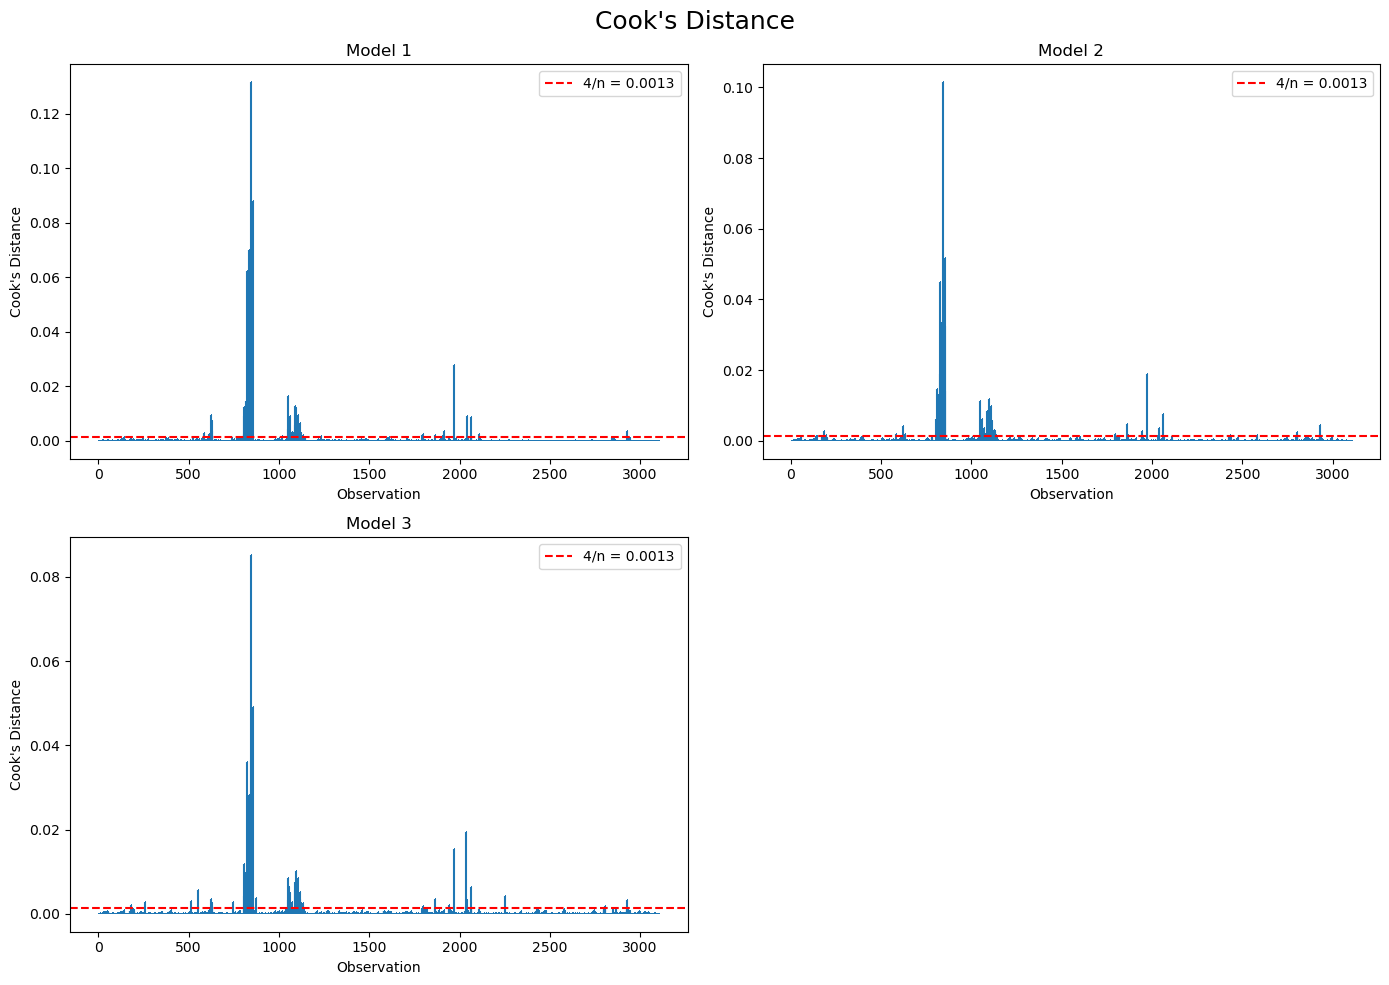

In [43]:
# ============================================================
# COOK'S DISTANCE (LIN FORM)
# ============================================================

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    influence = result.get_influence()

    cooks = influence.cooks_distance[0]

    ax.stem(
        np.arange(len(cooks)),
        cooks,
        markerfmt=",",
        basefmt=" "
    )

    cutoff = 4 / len(cooks)

    ax.axhline(
        cutoff,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'4/n = {cutoff:.4f}'
    )

    ax.set_title(name)
    ax.set_xlabel("Observation")
    ax.set_ylabel("Cook's Distance")

    ax.legend()

# hilangkan panel kosong
axes[1,1].axis("off")

plt.suptitle(
    "Cook's Distance",
    fontsize=18
)

plt.tight_layout()
plt.show()

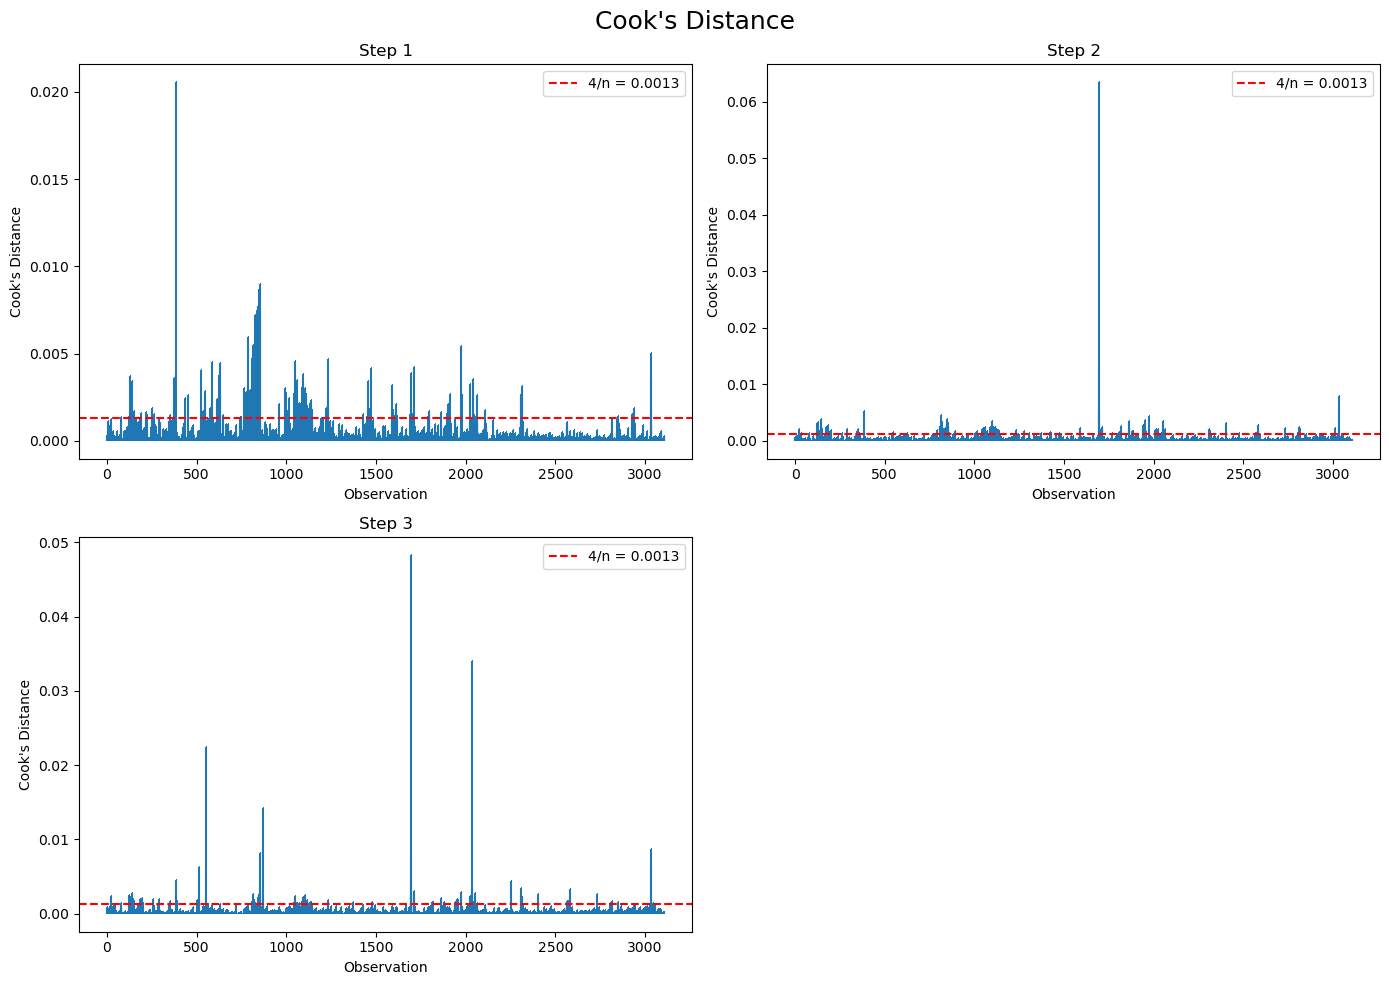

In [44]:
# ============================================================
# COOK'S DISTANCE (LOG FORM)
# ============================================================

models = {
    "Step 1": results_step1,
    "Step 2": results_step2,
    "Step 3": results_step3
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, (name, result) in zip(axes.flatten(), models.items()):

    influence = result.get_influence()

    cooks = influence.cooks_distance[0]

    ax.stem(
        np.arange(len(cooks)),
        cooks,
        markerfmt=",",
        basefmt=" "
    )

    cutoff = 4 / len(cooks)

    ax.axhline(
        cutoff,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'4/n = {cutoff:.4f}'
    )

    ax.set_title(name)
    ax.set_xlabel("Observation")
    ax.set_ylabel("Cook's Distance")

    ax.legend()

# hilangkan panel kosong
axes[1,1].axis("off")

plt.suptitle(
    "Cook's Distance",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# SHAPIRO-WILK TEST (LIN FORM)
# ============================================================

from scipy.stats import shapiro
import pandas as pd

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

results_shapiro = []

for name, result in models.items():

    stat, p = shapiro(result.resid)

    results_shapiro.append({
        "Model": name,
        "W Statistic": round(stat, 4),
        "p-value": round(p, 6),
        "Normal Residual?": "Yes" if p > 0.05 else "No"
    })

shapiro_df = pd.DataFrame(results_shapiro)

print("\nSHAPIRO-WILK TEST (MODEL 1–3)")
print("="*60)
print(shapiro_df)


SHAPIRO-WILK TEST (MODEL 1–3)
     Model  W Statistic  p-value Normal Residual?
0  Model 1       0.4744      0.0               No
1  Model 2       0.6218      0.0               No
2  Model 3       0.6249      0.0               No


In [46]:
# ============================================================
# SHAPIRO-WILK TEST (LOG FORM)
# ============================================================

models = {
    "Step 1": results_step1,
    "Step 2": results_step2,
    "Step 3": results_step3
}

results_shapiro = []

for name, result in models.items():

    stat, p = shapiro(result.resid)

    results_shapiro.append({
        "Model": name,
        "W Statistic": round(stat, 4),
        "p-value": round(p, 6),
        "Normal Residual?": "Yes" if p > 0.05 else "No"
    })

shapiro_step_df = pd.DataFrame(results_shapiro)

print("\nSHAPIRO-WILK TEST (STEP 1–3)")
print("="*60)
print(shapiro_step_df)


SHAPIRO-WILK TEST (STEP 1–3)
    Model  W Statistic  p-value Normal Residual?
0  Step 1       0.9739      0.0               No
1  Step 2       0.9944      0.0               No
2  Step 3       0.9919      0.0               No


In [47]:
# ============================================================
# BREUSCH-PAGAN TEST (LIN FORM)
# ============================================================

from statsmodels.stats.diagnostic import het_breuschpagan
import pandas as pd

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

bp_results = []

for name, result in models.items():

    bp = het_breuschpagan(
        result.resid,
        result.model.exog
    )

    bp_results.append({
        "Model": name,
        "LM Statistic": round(bp[0], 4),
        "p-value": round(bp[1], 6),
        "Homoskedastic?": "Yes" if bp[1] > 0.05 else "No"
    })

bp_original_df = pd.DataFrame(bp_results)

print("\nBREUSCH-PAGAN TEST (MODEL 1–3)")
print("="*70)
print(bp_original_df)


BREUSCH-PAGAN TEST (MODEL 1–3)
     Model  LM Statistic   p-value Homoskedastic?
0  Model 1       17.8604  0.000024             No
1  Model 2      216.8268  0.000000             No
2  Model 3      224.6771  0.000000             No


In [48]:
# ============================================================
# BREUSCH-PAGAN TEST (LOG FORM)
# ============================================================

models = {
    "Step 1": results_step1,
    "Step 2": results_step2,
    "Step 3": results_step3
}

bp_results = []

for name, result in models.items():

    bp = het_breuschpagan(
        result.resid,
        result.model.exog
    )

    bp_results.append({
        "Model": name,
        "LM Statistic": round(bp[0], 4),
        "p-value": round(bp[1], 6),
        "Homoskedastic?": "Yes" if bp[1] > 0.05 else "No"
    })

bp_step_df = pd.DataFrame(bp_results)

print("\nBREUSCH-PAGAN TEST (STEP 1–3)")
print("="*70)
print(bp_step_df)


BREUSCH-PAGAN TEST (STEP 1–3)
    Model  LM Statistic  p-value Homoskedastic?
0  Step 1       15.5507  0.00008             No
1  Step 2      199.2806  0.00000             No
2  Step 3      209.0060  0.00000             No


In [49]:
# ============================================================
# DURBIN-WATSON TEST (LIN FORM)
# ============================================================

from statsmodels.stats.stattools import durbin_watson
import pandas as pd

models = {
    "Model 1": results_m1,
    "Model 2": results_m2,
    "Model 3": results_m3
}

dw_results = []

for name, result in models.items():

    dw = durbin_watson(result.resid)

    if 1.5 <= dw <= 2.5:
        interpretation = "No autocorrelation"
    elif dw < 1.5:
        interpretation = "Positive autocorrelation"
    else:
        interpretation = "Negative autocorrelation"

    dw_results.append({
        "Model": name,
        "DW Statistic": round(dw, 3),
        "Interpretation": interpretation
    })

dw_original_df = pd.DataFrame(dw_results)

print("\nDURBIN-WATSON TEST (MODEL 1–3)")
print("="*70)
print(dw_original_df)


DURBIN-WATSON TEST (MODEL 1–3)
     Model  DW Statistic            Interpretation
0  Model 1         0.500  Positive autocorrelation
1  Model 2         0.612  Positive autocorrelation
2  Model 3         0.580  Positive autocorrelation


In [50]:
# ============================================================
# DURBIN-WATSON TEST (LOG FORM)
# ============================================================

models = {
    "Step 1": results_step1,
    "Step 2": results_step2,
    "Step 3": results_step3
}

dw_results = []

for name, result in models.items():

    dw = durbin_watson(result.resid)

    if 1.5 <= dw <= 2.5:
        interpretation = "No autocorrelation"
    elif dw < 1.5:
        interpretation = "Positive autocorrelation"
    else:
        interpretation = "Negative autocorrelation"

    dw_results.append({
        "Model": name,
        "DW Statistic": round(dw, 3),
        "Interpretation": interpretation
    })

dw_step_df = pd.DataFrame(dw_results)

print("\nDURBIN-WATSON TEST (STEP 1–3)")
print("="*70)
print(dw_step_df)


DURBIN-WATSON TEST (STEP 1–3)
    Model  DW Statistic            Interpretation
0  Step 1         0.617  Positive autocorrelation
1  Step 2         0.773  Positive autocorrelation
2  Step 3         0.681  Positive autocorrelation


In [51]:
jan_df = spatial_df[
    spatial_df["month"] == 1
].copy()

coords = list(
    zip(
        jan_df["centroid_lon"],
        jan_df["centroid_lat"]
    )
)

from libpysal.weights import KNN

w = KNN.from_array(
    coords,
    k=8
)

w.transform = "r"

In [52]:
print(
    len(
        results_m3.resid[
            df.loc[
                results_m3.model.data.row_labels,
                "month"
            ] == 1
        ]
    )
)

print(w.n)

458
458


In [53]:
# ============================================================
# MORAN'S I FUNCTION
# ============================================================

from esda.moran import Moran
from libpysal.weights import KNN

def calculate_moran(result, model_name):

    idx = result.model.data.row_labels

    temp = df.loc[
        idx,
        [
            "spatial_id",
            "year",
            "month"
        ]
    ].copy()

    temp["residual"] = result.resid.values

    temp = temp.merge(
        spatial_df[
            [
                "spatial_id",
                "year",
                "month",
                "centroid_lon",
                "centroid_lat"
            ]
        ],
        on=[
            "spatial_id",
            "year",
            "month"
        ],
        how="left"
    )

    # January only
    temp = temp[
        temp["month"] == 1
    ].copy()

    coords = list(
        zip(
            temp["centroid_lon"],
            temp["centroid_lat"]
        )
    )

    w = KNN.from_array(
        coords,
        k=8
    )

    w.transform = "r"

    moran = Moran(
        temp["residual"],
        w
    )

    return moran

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
# ============================================================
# CREATE MORAN OBJECTS
# ============================================================

moran_m1 = calculate_moran(
    results_m1,
    "Linear Model 1"
)

moran_m2 = calculate_moran(
    results_m2,
    "Linear Model 2"
)

moran_m3 = calculate_moran(
    results_m3,
    "Linear Model 3"
)

moran_s1 = calculate_moran(
    results_step1,
    "Log Step 1"
)

moran_s2 = calculate_moran(
    results_step2,
    "Log Step 2"
)

moran_s3 = calculate_moran(
    results_step3,
    "Log Step 3"
)

In [55]:
# ============================================================
# MORAN'S I RESULTS
# ============================================================

moran_results = pd.DataFrame({

    "Model": [
        "Linear M1",
        "Linear M2",
        "Linear M3",
        "Log S1",
        "Log S2",
        "Log S3"
    ],

    "Moran_I": [
        moran_m1.I,
        moran_m2.I,
        moran_m3.I,
        moran_s1.I,
        moran_s2.I,
        moran_s3.I
    ],

    "p_value": [
        moran_m1.p_sim,
        moran_m2.p_sim,
        moran_m3.p_sim,
        moran_s1.p_sim,
        moran_s2.p_sim,
        moran_s3.p_sim
    ]

})

moran_results

,Model,Moran_I,p_value
0,Linear M1,0.217284,0.001
1,Linear M2,0.209653,0.001
2,Linear M3,0.219560,0.001
3,Log S1,0.126454,0.001
4,Log S2,0.128417,0.001
5,Log S3,0.135628,0.001


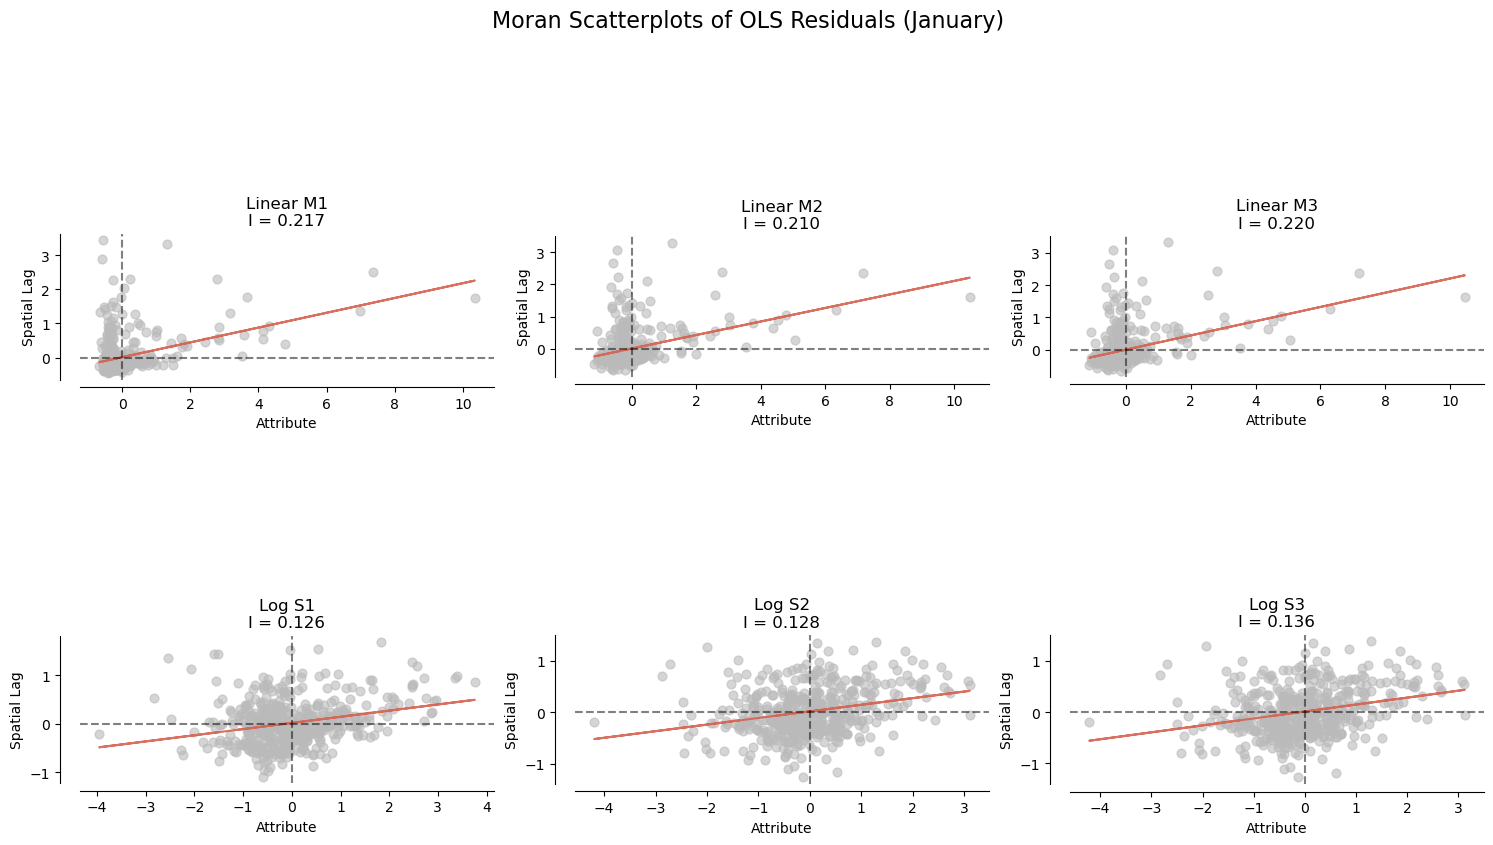

In [56]:
# ============================================================
# MORAN SCATTERPLOTS
# ============================================================

from splot.esda import moran_scatterplot

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,10)
)

models = [

    (moran_m1, "Linear M1"),
    (moran_m2, "Linear M2"),
    (moran_m3, "Linear M3"),

    (moran_s1, "Log S1"),
    (moran_s2, "Log S2"),
    (moran_s3, "Log S3")
]

for ax, (moran_obj, title) in zip(
    axes.flatten(),
    models
):

    moran_scatterplot(
        moran_obj,
        ax=ax
    )

    ax.set_title(
        f"{title}\nI = {moran_obj.I:.3f}"
    )

plt.suptitle(
    "Moran Scatterplots of OLS Residuals (January)",
    fontsize=16
)

plt.tight_layout()

plt.show()